# FInal Project

Daniel Ott (33551440), Samuel Šmíd (73123255), Anna Turnerová (70701808)

## Packages

In [3]:
library(fst)
library(highfrequency)
library(xts)
library(rugarch)
library(forecast)
library(zoo)
library(ggplot2)
library(tidyr)

Warning message:
"package 'fst' was built under R version 4.5.3"
Warning message:
"package 'highfrequency' was built under R version 4.5.3"
Warning message:
"package 'xts' was built under R version 4.5.2"
Loading required package: zoo


Attaching package: 'zoo'


The following objects are masked from 'package:base':

    as.Date, as.Date.numeric


Warning message:
"package 'rugarch' was built under R version 4.5.2"
Loading required package: parallel

Warning message:
"package 'forecast' was built under R version 4.5.2"
Warning message:
"package 'tidyr' was built under R version 4.5.2"


## Data Preparation

In [4]:
data <- load("data_project/26.RData")   # loads the .RData file into the environment
head(data)                               # shows the name of object stored in the file
asset_data <- get(data[1])              # retrieves the first object by name
head(asset_data)                        

[1] "amat"

                    ret         RV        RV_p        RV_n          RS       RK
2010-01-05  0.010600358 0.01537440 0.010802724 0.010939525  0.22027109 4.607369
2010-01-06 -0.002112787 0.01482381 0.011268814 0.009631161  0.58156996 3.443174
2010-01-07 -0.004239012 0.01455766 0.009431595 0.011089210 -0.53822008 4.062540
2010-01-08  0.006351798 0.01627584 0.012371915 0.010575383  0.02566745 4.681865
2010-01-11  0.041973644 0.02193678 0.013281618 0.017459120 -1.15919678 5.918139
2010-01-12 -0.006089911 0.02460140 0.014433799 0.019922207 -0.60888995 3.864707

"amat" is the ticker symbol for Applied Materials, Inc. (AMAT) - a large US semiconductor equipment company traded on NASDAQ. So our asset (#26) is the daily realized volatility data for Applied Materials stock, starting from January 2010.

### Data Quality Checks

Before we start estimating our models, we need to check for data quality issues that could potentially break our models. We check for four conditions: missing values (NAs) in returns, missing values in Realised Volatility (RV), exact zero returns, and non-positive RV values. Missing data fundamentally disrupts time-series continuity, breaking both OLS and Maximum Likelihood (MLE) estimators. Exact zero returns flatten the optimization gradient, potentially causing the GARCH Hessian matrix to fail inversion. Lastly, zero or negative RV values trigger mathematically undefined logarithmic operations within the realGARCH measurement equation.

In [5]:
# --- Initial Checks ---
cat("Missing in Returns:", sum(is.na(asset_data$ret)), "\n")
cat("Missing in RV:", sum(is.na(asset_data$RV)), "\n")

zero_rows <- which(asset_data$ret == 0)
bad_rv <- sum(asset_data$RV <= 0, na.rm = TRUE)

cat("Zero Returns:", length(zero_rows), "\n")
cat("Zero/Negative RV:", bad_rv, "\n\n")

Missing in Returns: 0 
Missing in RV: 0 
Zero Returns: 16 
Zero/Negative RV: 0 



We find that the only defect present are 16 instances of zero returns. While inter-day returns certainly can take on zero values (US equity prices have a minimum tick size of $0.01), we need to deal with them somehow, since they could potentially cause our GARCH models - estimated via MLE - to fail to converge. Let us now print short intervals around these zero values to investigate the origin of these zero values.

In [6]:
# --- Print Zero Windows ---
if (length(zero_rows) > 0) {
    for (i in 1:length(zero_rows)) {
        row_idx <- zero_rows[i]
        start_idx <- max(1, row_idx - 2)
        end_idx <- min(nrow(asset_data), row_idx + 2)
        
        cat("Window:", as.character(index(asset_data)[row_idx]), "\n")
        print(asset_data[start_idx:end_idx, c("ret", "RV")])
        cat("\n")
    }
}

Window: 2010-10-14 
                    ret         RV
2010-10-12  0.017055159 0.01641553
2010-10-13  0.014271636 0.01649048
2010-10-14  0.000000000 0.01552123
2010-10-15  0.004159068 0.01717744
2010-10-18 -0.005827551 0.01352247

Window: 2010-12-30 
                     ret          RV
2010-12-28  0.0071535977 0.006264003
2010-12-29  0.0085272414 0.007729041
2010-12-30  0.0000000000 0.006438096
2010-12-31 -0.0007119736 0.009558380
2011-01-03  0.0000000000 0.013812577

Window: 2011-01-03 
                     ret          RV
2010-12-30  0.0000000000 0.006438096
2010-12-31 -0.0007119736 0.009558380
2011-01-03  0.0000000000 0.013812577
2011-01-04 -0.0049647671 0.010664788
2011-01-05 -0.0164897688 0.010349553

Window: 2011-06-30 
                   ret         RV
2011-06-28 0.023111368 0.01328752
2011-06-29 0.003153168 0.01252186
2011-06-30 0.000000000 0.01263422
2011-07-01 0.022518956 0.01556065
2011-07-05 0.022031703 0.01243611

Window: 2011-10-18 
                    ret         RV
201

Examining the windows around our zero values, we can see that even though the return is zero, RV takes on non-zero values. This indicates that trading occured on the zero-return days and the price just came back to the value at the start of the day. This means that we cannot omit these observations, as they are fully valid data points. Therefore, we opt to add a microscopic constant ($10^{-6}$) to the zero returns. This resolves the MLE convergence failure without empirically biasing the parameter estimates.

In [7]:
# --- Apply Fixes ---
if (length(zero_rows) > 0) {
    asset_data$ret[asset_data$ret == 0] <- 1e-6
}


## Exploratory analysis

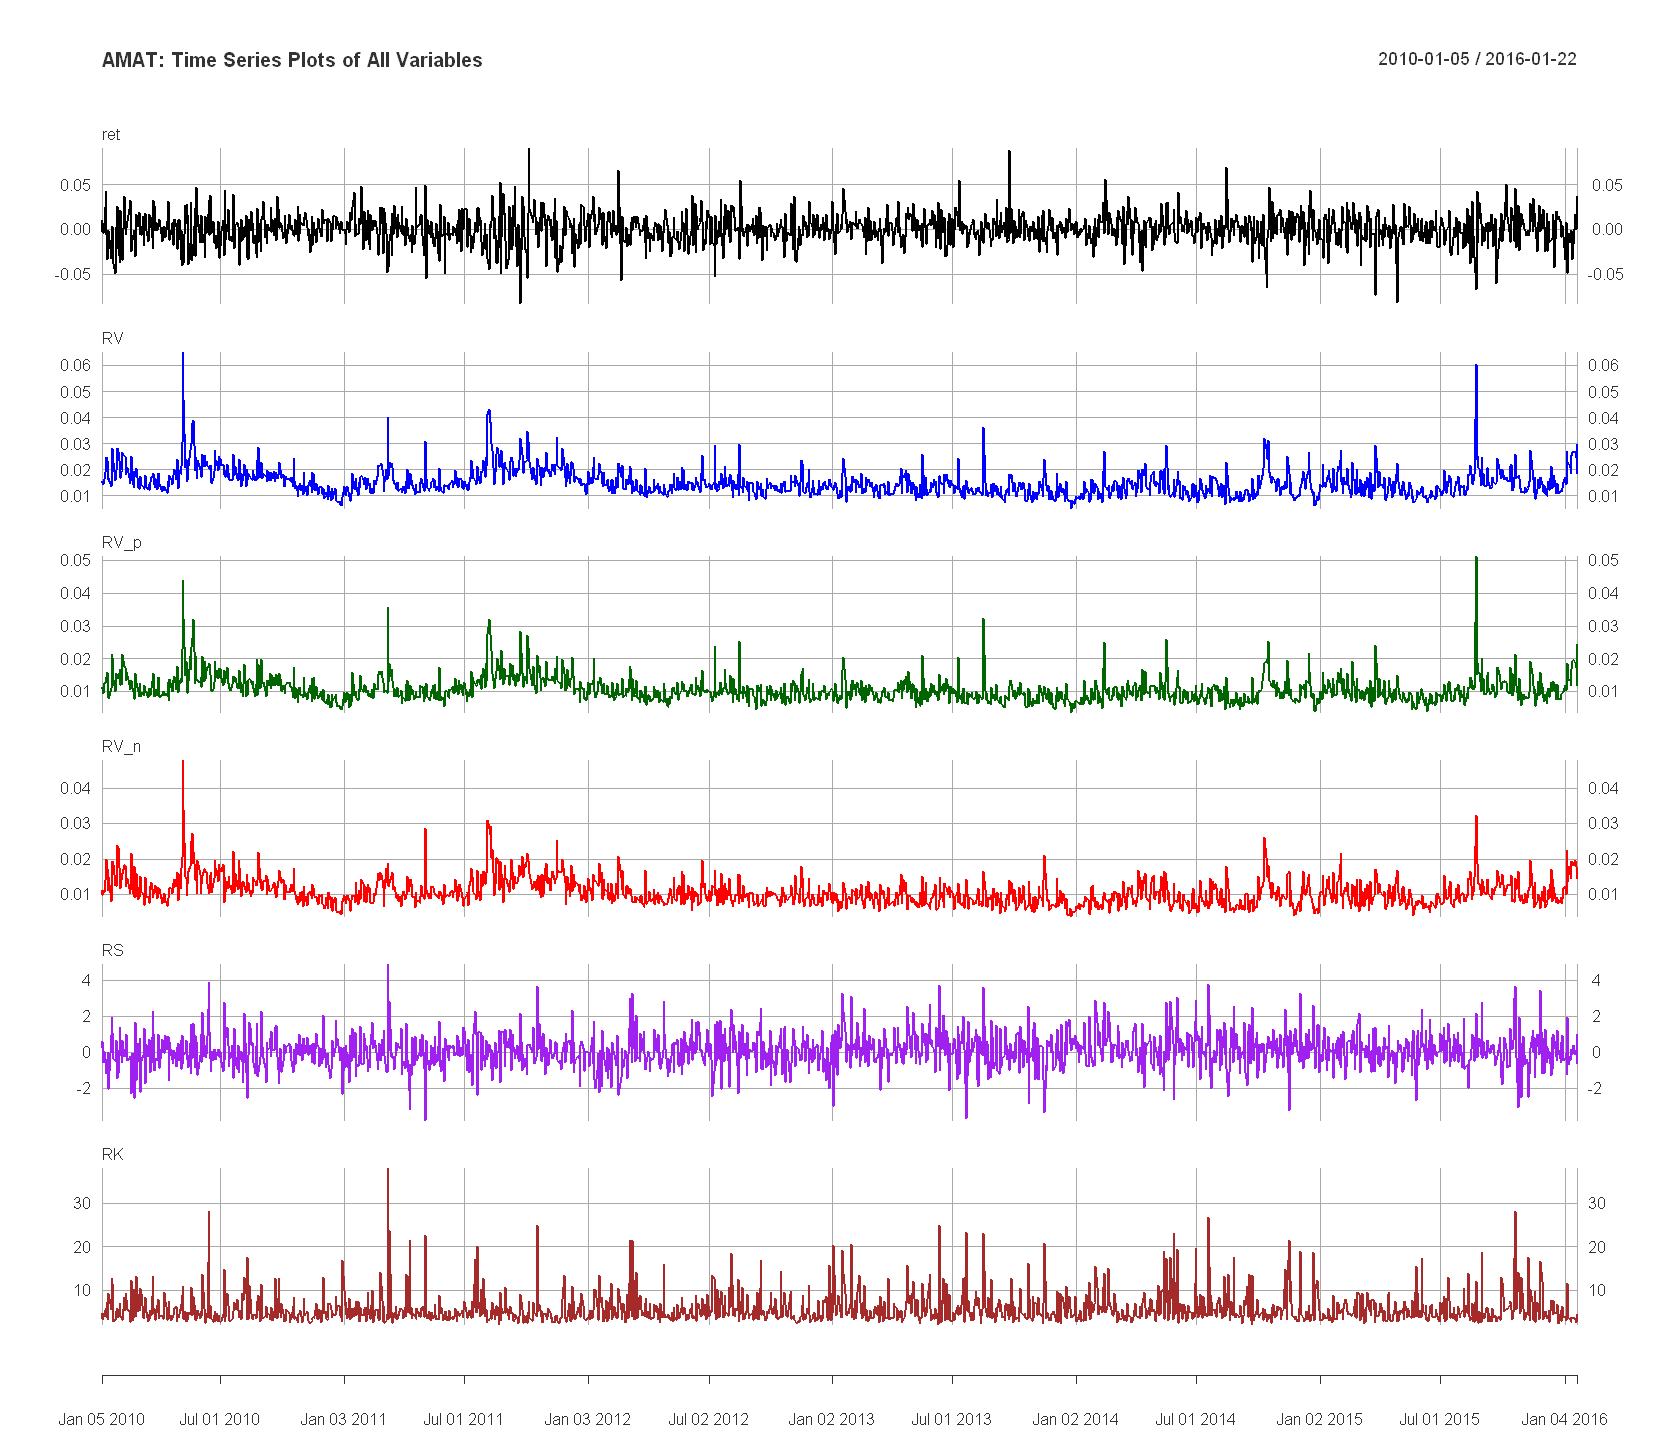

In [8]:
options(repr.plot.width = 14, repr.plot.height = 12)
plot.xts(asset_data, 
         multi.panel = TRUE, 
         yaxis.same = FALSE,
         col = c("black", "blue", "darkgreen", "red", "purple", "brown"),
         main = "AMAT: Time Series Plots of All Variables")

In [9]:
# descriptive statistics
summary(coredata(asset_data)) # view the summary of all columns except the index column

      ret                   RV                RV_p               RV_n         
 Min.   :-0.0831897   Min.   :0.005378   Min.   :0.003804   Min.   :0.003802  
 1st Qu.:-0.0096931   1st Qu.:0.011861   1st Qu.:0.008198   1st Qu.:0.007937  
 Median : 0.0008695   Median :0.014288   Median :0.010081   Median :0.009841  
 Mean   : 0.0002284   Mean   :0.015212   Mean   :0.010768   Mean   :0.010558  
 3rd Qu.: 0.0106051   3rd Qu.:0.017221   3rd Qu.:0.012362   3rd Qu.:0.012405  
 Max.   : 0.0906058   Max.   :0.065073   Max.   :0.051231   Max.   :0.047888  
       RS                 RK        
 Min.   :-3.76626   Min.   : 2.237  
 1st Qu.:-0.48534   1st Qu.: 3.636  
 Median : 0.07282   Median : 4.607  
 Mean   : 0.10153   Mean   : 5.713  
 3rd Qu.: 0.62721   3rd Qu.: 6.383  
 Max.   : 4.86950   Max.   :37.962  

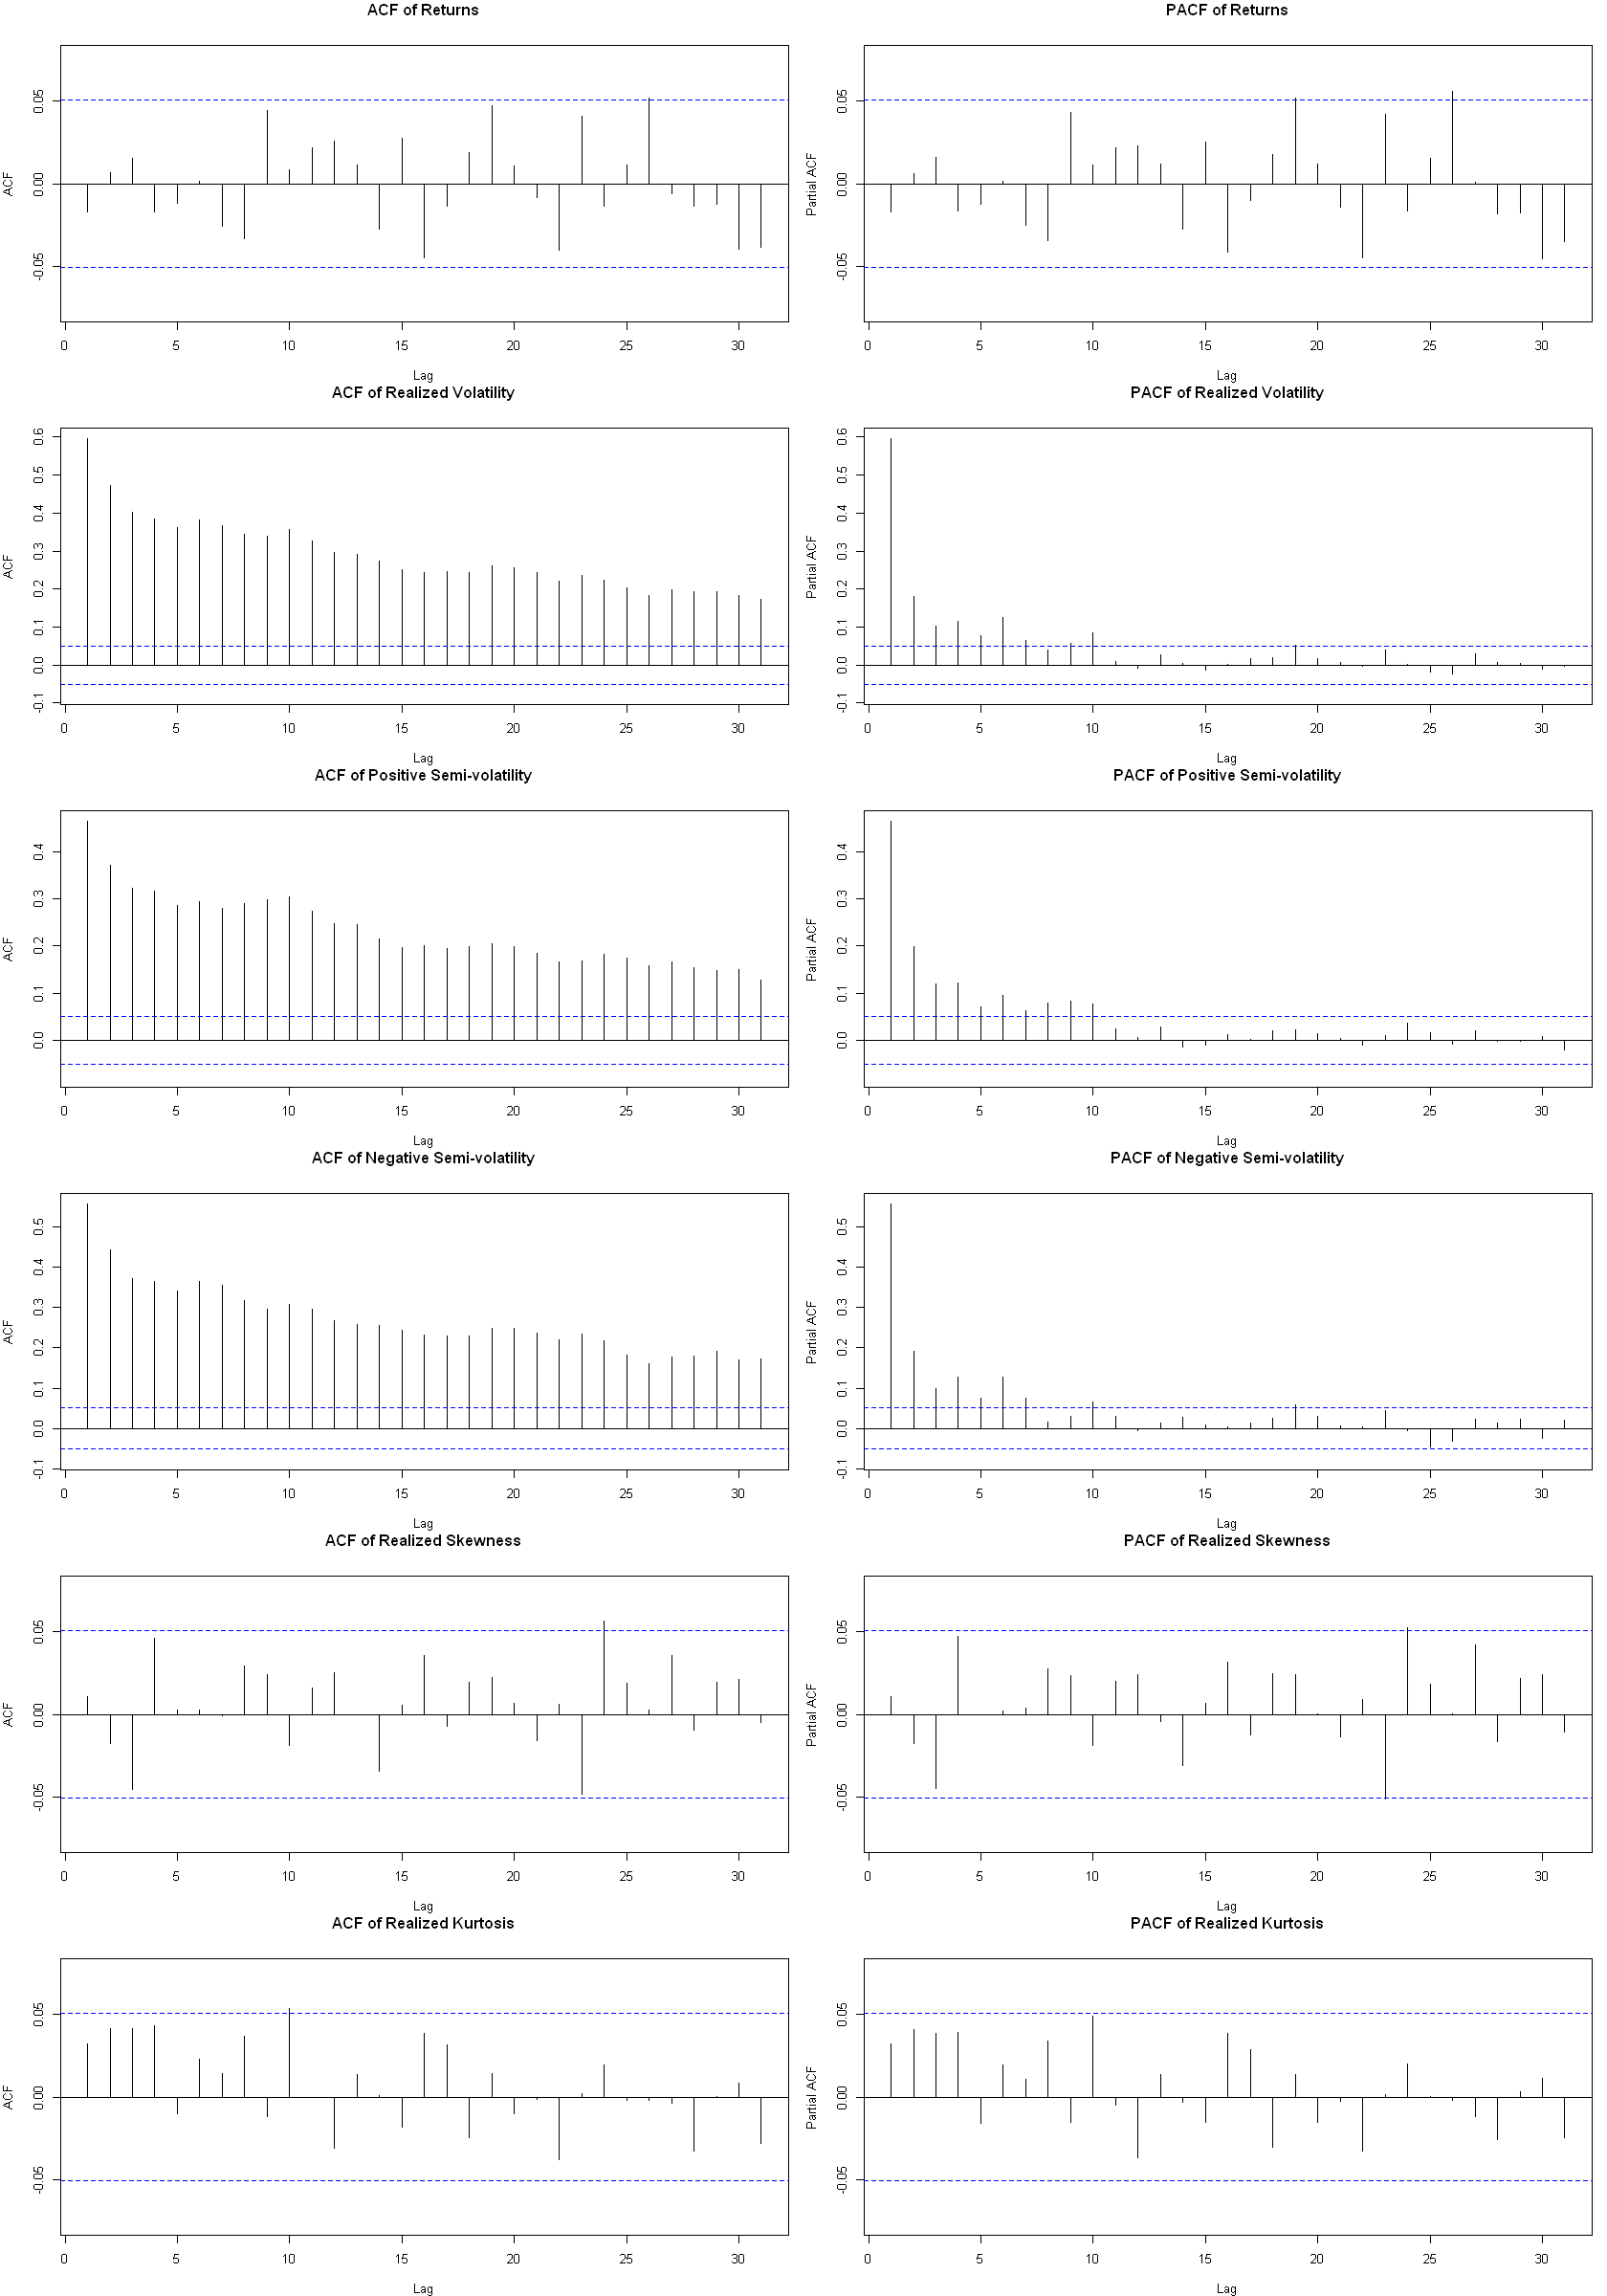

In [10]:
options(repr.plot.width = 14, repr.plot.height = 20)
par(mfrow = c(6, 2), mar = c(4, 4, 3, 1))

#ret
Acf(asset_data$ret, main = "ACF of Returns")
Pacf(asset_data$ret, main = "PACF of Returns")

#rv
Acf(asset_data$RV, main = "ACF of Realized Volatility")
Pacf(asset_data$RV, main = "PACF of Realized Volatility")

#rvp
Acf(asset_data$RV_p, main = "ACF of Positive Semi-volatility")
Pacf(asset_data$RV_p, main = "PACF of Positive Semi-volatility")

#rvn
Acf(asset_data$RV_n, main = "ACF of Negative Semi-volatility")
Pacf(asset_data$RV_n, main = "PACF of Negative Semi-volatility")
#rs
Acf(asset_data$RS, main = "ACF of Realized Skewness")
Pacf(asset_data$RS, main = "PACF of Realized Skewness")
#rk
Acf(asset_data$RK, main = "ACF of Realized Kurtosis")
Pacf(asset_data$RK, main = "PACF of Realized Kurtosis")


par(mfrow = c(1, 1))

The dataset covers 2010-01-05 to 2016-01-22, providing approximately 1,509 daily observations for AMAT. Each observation contains the daily log return and five realized measures computed from 5-minute intraday data.

### Returns (`ret`)

The time series plot shows daily log returns fluctuating around zero with no visible trend or drift throughout the entire sample. The distribution is roughly symmetric (mean ≈ 0.0002, median ≈ 0.0009), which we would expect for daily returns. The minimum and maximum correspond to single-day moves of -8.3% and +9.1% respectively, far larger than a normal distribution would imply, indicating that the returns have fatter tails than the normal distribution. Periods of larger swings are visually clustered — particularly around 2010–2011 and 2015–2016 — revealing the phenomenon of volatility clustering in equity returns.

The ACF and PACF of returns are almost entirely within the 95% confidence bands across all 32 lags, with only a few marginal crossings consistent with chance at the 5% level. This confirms that daily returns are serially uncorrelated, in line with the weak form of market efficiency: past returns carry no significant linear information about future returns.


### Realized Volatility (`RV`)

The time series of RV makes the volatility clustering visible in a much cleaner way than returns alone. RV oscillates around a baseline of approximately 0.014–0.015, with some sharp upward spikes — most prominent in early 2010 and again in 2015–2016. The distribution is clearly right-skewed: the mean (0.0152) exceeds the median (0.0143), and the maximum (0.0651) is more than 4× the median, reflecting the heavy right tail typical of realized volatility measures.

The ACF of RV starts at approximately 0.6 at lag 1 and decays very slowly, remaining statistically significant well beyond lag 30. This slow, gradual decay indicates high persistence, consistent with either long memory or near-unit-root dynamics. The PACF shows one dominant spike at lag 1 (~0.6), followed by a few smaller significant partial autocorrelations at lags 2–5, and then rapid decay toward zero. This combination — slowly decaying ACF with a sharp PACF cutoff — rules out a simple AR(1) and motivates richer models capable of capturing persistence across multiple horizons, most naturally the HAR model.

### Positive and Negative Semi-volatilities (`RV_p`, `RV_n`)

Both semi-volatility series closely mirror the shape of RV in the time series plot, which is expected by construction since $\text{RV}_t \approx \text{RV}^+_t + \text{RV}^-_t$. This is confirmed in the summary statistics: the means sum closely to the mean of RV ($0.0108 + 0.0106 \approx 0.0214$). On average, positive and negative intraday variation are nearly symmetric, though subtle asymmetries are visible during stress episodes — for instance, the early-2010 spike appears somewhat more pronounced in `RV_n`, suggesting a downside-driven event.

The ACF and PACF structures of both series are nearly identical to those of RV: slowly decaying ACF with significant autocorrelations through lag 30+, and a dominant PACF spike at lag 1 followed by rapid decay. This shared persistence structure is the motivation for the HAR-RS model, which decomposes RV into its positive and negative components to test whether intraday asymmetry carries incremental predictive content beyond total variation.

### Realized Skewness (`RS`)

In contrast to the volatility measures, RS fluctuates around zero with no visible persistence or clustering in the time series. The mean is slightly positive (0.10), indicating a marginal upward bias in intraday price moves on average, but the wide range (-3.77 to +4.87) and large IQR confirm high day-to-day variability.

The ACF and PACF of RS are almost entirely within the confidence bands — RS is close to white noise in its own dynamics. This is consistent with RS capturing the direction of intraday jumps, which is largely unpredictable from the past. Importantly, this does not make RS irrelevant as a predictor: in the HAR-RS and HAR-Moments models, today's skewness may still help forecast tomorrow's RV, even if past skewness cannot forecast future skewness.

### Realized Kurtosis (`RK`)

RK is always well above 3 throughout the sample — the mean is 5.71 and the median is 4.61 — confirming that intraday return distributions are fat-tailed every single day, not just during crises. Extreme values (up to 37.96) appear as isolated spikes in the time series, likely corresponding to earnings announcements or macro surprises, rather than as persistent regimes.

Like RS, the ACF and PACF of RK show no meaningful persistence — both are largely within the confidence bands across all lags. The day-to-day level of excess kurtosis is essentially unpredictable from its own past. As with RS, RK may nonetheless carry predictive value for future RV as a regressor in the HAR-Moments model, capturing the information content of extreme intraday moves for next-day volatility.

## Modelling - In-Sample Characteristics

### Data Preparation

In [11]:
#rv lagged daily
RV_1 <- lag(asset_data$RV, 1)
#rolling weekly and monthly averages
RV_5 <- rollmean(RV_1, k = 5, fill = NA, align = "right")
RV_22 <- rollmean(RV_1, k = 22, fill = NA, align = "right")

In [12]:
#kurtosis and skeweness daily lags
RS_1 <- lag(asset_data$RS, 1)
RK_1 <- lag(asset_data$RK, 1)

In [13]:
#create dataset we will use for the regressions
har_data <- merge(asset_data$RV, RV_1, RV_5, RV_22, RS_1, RK_1)
colnames(har_data) <- c("RV", "RV_1", "RV_5", "RV_22", "RS_1", "RK_1")
har_data <- na.omit(har_data)
head(har_data)

                   RV       RV_1       RV_5      RV_22        RS_1     RK_1
2010-02-05 0.02657759 0.01996497 0.02066632 0.02003278 -0.58567243 3.312116
2010-02-08 0.02530772 0.02657759 0.02055692 0.02054201  0.66537303 3.085123
2010-02-09 0.02521336 0.02530772 0.02156734 0.02101855 -0.21735552 8.374643
2010-02-10 0.01815253 0.02521336 0.02325089 0.02150290 -0.05696237 5.464957
2010-02-11 0.02047238 0.01815253 0.02304323 0.02158821  0.82791989 9.356345
2010-02-12 0.02081424 0.02047238 0.02314472 0.02152164  0.98267322 7.889675

### Autoregressive RV models

In [14]:
fit_ar1 <- lm(RV ~ RV_1, data = har_data)
summary(fit_ar1)


Call:
lm(formula = RV ~ RV_1, data = har_data)

Residuals:
      Min        1Q    Median        3Q       Max 
-0.017874 -0.002509 -0.000494  0.001867  0.043466 

Coefficients:
             Estimate Std. Error t value Pr(>|t|)    
(Intercept) 0.0061619  0.0003353   18.38   <2e-16 ***
RV_1        0.5929793  0.0209537   28.30   <2e-16 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Residual standard error: 0.004172 on 1476 degrees of freedom
Multiple R-squared:  0.3517,	Adjusted R-squared:  0.3513 
F-statistic: 800.9 on 1 and 1476 DF,  p-value: < 2.2e-16


First, we estimate a simple AR(1)-RV model, regressing Realised Volatility on its lagged analogue. The coefficient corresponding to lagged RV is estimated at $\beta_d \approx 0.593$, confirming that realised volatility in AMAT returns is highly persistent - 59.3 \% of today's intraday volatility carries over to tomorrow, on top of the long-term constant. Overall, this one-day lookback explains approximately 35.1% of the total variation in the next day's volatility.

In [15]:
fit_har <- lm(RV ~ RV_1 + RV_5 + RV_22, data = har_data)
summary(fit_har)


Call:
lm(formula = RV ~ RV_1 + RV_5 + RV_22, data = har_data)

Residuals:
      Min        1Q    Median        3Q       Max 
-0.011768 -0.002460 -0.000483  0.001743  0.044105 

Coefficients:
             Estimate Std. Error t value Pr(>|t|)    
(Intercept) 0.0020934  0.0004935   4.242 2.35e-05 ***
RV_1        0.3766901  0.0298776  12.608  < 2e-16 ***
RV_5        0.1936273  0.0513401   3.771 0.000169 ***
RV_22       0.2917077  0.0514587   5.669 1.73e-08 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Residual standard error: 0.004001 on 1474 degrees of freedom
Multiple R-squared:  0.4045,	Adjusted R-squared:  0.4033 
F-statistic: 333.8 on 3 and 1474 DF,  p-value: < 2.2e-16


Next, a standard HAR model is estimated, adding weekly and monthly realised volatility into the equation. With this addition, in-sample performance is drastically increased, as $R^2$ jumps to approximately 40.3 %.

Let us examine the estimates and look for differences from the AR(1)-RV model. First notable change is the fact that the long-term constant volatility dropped to a third of its value under AR(1)-RV. This is likely because some of the volatility persistence, previously invisible to the AR(1)'s one-day lookback, was incorrectly absorbed into its baseline constant. Furthermore, the daily coefficient drops from 0.593 to roughly 0.376. In the AR(1) model, this daily lag acted as a proxy for all historical information. Now, the persistence is distributed across horizons: approximately 37.6% of yesterday's volatility, 19.3% of last week's average, and 29.1% of last month's average carry over to tomorrow. Together, these yield a combined implied persistence of about 86%, confirming that AMAT's volatility memory extends far beyond a single day.

In [16]:
fit_har_rs <- lm(RV ~ RV_1 + RV_5 + RV_22 + RS_1, data = har_data)
summary(fit_har_rs)


Call:
lm(formula = RV ~ RV_1 + RV_5 + RV_22 + RS_1, data = har_data)

Residuals:
      Min        1Q    Median        3Q       Max 
-0.012284 -0.002370 -0.000505  0.001669  0.043888 

Coefficients:
              Estimate Std. Error t value Pr(>|t|)    
(Intercept)  0.0021439  0.0004923   4.355 1.42e-05 ***
RV_1         0.3799448  0.0298084  12.746  < 2e-16 ***
RV_5         0.1929511  0.0511902   3.769  0.00017 ***
RV_22        0.2880479  0.0513215   5.613 2.38e-08 ***
RS_1        -0.0003278  0.0001054  -3.110  0.00191 ** 
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Residual standard error: 0.00399 on 1473 degrees of freedom
Multiple R-squared:  0.4084,	Adjusted R-squared:  0.4068 
F-statistic: 254.2 on 4 and 1473 DF,  p-value: < 2.2e-16


Upgrading to the HAR-RS model by introducing lagged realised skewness ($RS_1$) yields only a marginal improvement in overall fit, with the Adjusted $R^2$ ticking up from 40.3% to roughly 40.7%. The core volatility coefficients ($\beta_d, \beta_w, \beta_m$) experience only slight shifts, preserving the implied persistence at around 86%.The true value of this addition lies in the skewness term itself. The coefficient is negative ($\gamma_1 \approx -0.00033$) and statistically significant, which empirically confirms the leverage effect: a negatively skewed intraday return distribution (characterised by downside price action) systematically drives higher volatility the following day. However, this leverage effect is small in magnitude compared to the effect of lagged RV, even after adjusting for scale - showing that past volatility is still the main driver of future volatility in this model.

In [17]:
fit_har_rs_rk <- lm(RV ~ RV_1 + RV_5 + RV_22 + RS_1 + RK_1, data = har_data)
summary(fit_har_rs_rk)


Call:
lm(formula = RV ~ RV_1 + RV_5 + RV_22 + RS_1 + RK_1, data = har_data)

Residuals:
      Min        1Q    Median        3Q       Max 
-0.012699 -0.002407 -0.000569  0.001752  0.043414 

Coefficients:
              Estimate Std. Error t value Pr(>|t|)    
(Intercept)  0.0029523  0.0005182   5.697 1.47e-08 ***
RV_1         0.4218794  0.0309120  13.648  < 2e-16 ***
RV_5         0.1531073  0.0515291   2.971  0.00301 ** 
RV_22        0.2867756  0.0509585   5.628 2.18e-08 ***
RS_1        -0.0002135  0.0001075  -1.987  0.04713 *  
RK_1        -0.0001457  0.0000310  -4.701 2.82e-06 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Residual standard error: 0.003961 on 1472 degrees of freedom
Multiple R-squared:  0.4172,	Adjusted R-squared:  0.4152 
F-statistic: 210.7 on 5 and 1472 DF,  p-value: < 2.2e-16


Finally, extending the model to include lagged realised kurtosis ($RK_1$) yields our best-fitting linear specification, pushing the Adjusted $R^2$ to roughly 41.5%. The newly added kurtosis term is highly significant and negative ($\gamma_2 \approx -0.000146$), indicating that the 'fatness' of the intraday tails - or the presence of extreme intraday price jumps - provides unique predictive power. Interestingly, introducing kurtosis slightly weakens the leverage effect, as the $RS_1$ coefficient drops to $-0.00021$. This suggests that part of the asymmetric downside reaction captured in the previous model was actually driven by these extreme tail events. Nevertheless, while mapping the exact shape of the intraday distribution through skewness and kurtosis provides a statistically robust fine-tuning mechanism, the core autoregressive weights remain dominant. Past realised volatility is still the undisputed engine of the forecast.

### GARCH Models

In [18]:
spec_garch <- ugarchspec(
  mean.model = list(armaOrder = c(0, 0), include.mean = TRUE),
  variance.model = list(model = "sGARCH", garchOrder = c(1, 1))
)
fit_garch <- ugarchfit(spec = spec_garch, data = asset_data$ret)
show(fit_garch)


*---------------------------------*
*          GARCH Model Fit        *
*---------------------------------*

Conditional Variance Dynamics 	
-----------------------------------
GARCH Model	: sGARCH(1,1)
Mean Model	: ARFIMA(0,0,0)
Distribution	: norm 

Optimal Parameters
------------------------------------
        Estimate  Std. Error  t value Pr(>|t|)
mu      0.000477    0.000444   1.0723  0.28357
omega   0.000014    0.000000  52.7370  0.00000
alpha1  0.037752    0.002717  13.8965  0.00000
beta1   0.918707    0.006089 150.8883  0.00000

Robust Standard Errors:
        Estimate  Std. Error  t value Pr(>|t|)
mu      0.000477    0.000469   1.0157  0.30977
omega   0.000014    0.000000  33.3384  0.00000
alpha1  0.037752    0.003356  11.2489  0.00000
beta1   0.918707    0.007560 121.5204  0.00000

LogLikelihood : 3940.272 

Information Criteria
------------------------------------
                    
Akaike       -5.2484
Bayes        -5.2342
Shibata      -5.2484
Hannan-Quinn -5.2431

Weig

To contrast these high-frequency models, we estimate a standard ARMA(0,0)-sGARCH(1,1). By specifying a constant mean, we explicitly assume daily returns are unpredictable noise, isolating our focus entirely on variance dynamics while ensuring computational stability. The model yields highly significant ARCH ($\alpha_1 \approx 0.037$) and GARCH ($\beta_1 \approx 0.919$) terms, combining for an implied persistence of roughly 95.7% - noticeably higher than the 86% captured by the HAR family. 

This discrepancy stems directly from a difference in data granularity. Lacking access to intraday information, the standard GARCH must infer volatility strictly from low-frequency daily returns. To compensate for this limited visibility, it heavily overweights its own past variance estimates ($\beta_1$) and mutes its sensitivity to new daily shocks ($\alpha_1$). This massive recursive anchor makes the model structurally rigid. Consequently, visual inspection of the in-sample fit reveals a noticeably sluggish trajectory that severely underreacts to sudden volatility spikes, missing the sharp actual RV peaks successfully tracked by the HAR models.

However, this rigidity is a limitation of the data inputs, not necessarily the underlying architecture. To combine the mathematical robustness of the GARCH framework with the empirical precision of high-frequency data, we turn to our final in-sample specification: the Realised GARCH (realGARCH).

In [19]:
spec_real <- ugarchspec(
  mean.model = list(armaOrder = c(0, 0), include.mean = TRUE),
  variance.model = list(model = "realGARCH", garchOrder = c(1, 1))
)
# Note: hybrid solver is often more robust for Realized GARCH
fit_garch_real <- ugarchfit(spec = spec_real, data = asset_data$ret, 
                           solver = "hybrid", realizedVol = asset_data$RV)
show(fit_garch_real)


*---------------------------------*
*          GARCH Model Fit        *
*---------------------------------*

Conditional Variance Dynamics 	
-----------------------------------
GARCH Model	: realGARCH(1,1)
Mean Model	: ARFIMA(0,0,0)
Distribution	: norm 

Optimal Parameters
------------------------------------
        Estimate  Std. Error  t value Pr(>|t|)
mu      0.000425    0.000416   1.0226 0.306502
omega  -0.362770    0.275919  -1.3148 0.188586
alpha1  0.819291    0.105394   7.7736 0.000000
beta1   0.530957    0.045924  11.5616 0.000000
eta11  -0.031881    0.005938  -5.3685 0.000000
eta21   0.026721    0.002837   9.4199 0.000000
delta   0.450236    0.037470  12.0160 0.000000
lambda  0.221749    0.004079  54.3654 0.000000
xi     -0.555772    0.305901  -1.8168 0.069242

Robust Standard Errors:
        Estimate  Std. Error  t value Pr(>|t|)
mu      0.000425    0.000431  0.98608 0.324095
omega  -0.362770    0.457599 -0.79277 0.427912
alpha1  0.819291    0.187079  4.37940 0.000012
beta1

By incorporating high-frequency realised volatility directly into the variance equation, the realGARCH model alters these mechanics. Utilising this granular data, the model's recursive parameter decreases ($\beta_1 \approx 0.531$), while its sensitivity to the daily realised measure increases ($\alpha_1 \approx 0.819$). Accounting for the measurement equation scaling ($\delta \approx 0.450$), the implied persistence ($\beta_1 + \alpha_1\delta$) is approximately 90%, remaining stationary and consistent with the long-memory dynamics observed in the HAR models. This specification yields a sizeable increase in log likelihood (from 3940 to 4130) and produces a visual fit that captures the sharp RV peaks missed by the standard model. Having evaluated the in-sample fit of both frameworks, we now proceed to out-of-sample forecasting to assess their relative predictive performance.

### Visual Fit Comparison

In [20]:
fitted_ar1 <- xts(fitted(fit_ar1), order.by = index(har_data))
fitted_har <- xts(fitted(fit_har), order.by = index(har_data))
fitted_har_rs <- xts(fitted(fit_har_rs), order.by = index(har_data))
fitted_har_rs_rk <- xts(fitted(fit_har_rs_rk), order.by = index(har_data))
fitted_garch <- xts(sigma(fit_garch), order.by = index(asset_data$ret))
fitted_garch_real <- xts(sigma(fit_garch_real), order.by = index(asset_data$ret))


In [21]:
fit_comparison <- merge(asset_data$RV, fitted_ar1, fitted_har, fitted_har_rs, fitted_har_rs_rk, fitted_garch, fitted_garch_real)
colnames(fit_comparison) <- c("Actual_RV", "AR1_Fit", "HAR_Fit", "HAR_rs_Fit", "HAR_rs_rk_Fit", "GARCH_Fit", "RealGARCH_Fit")

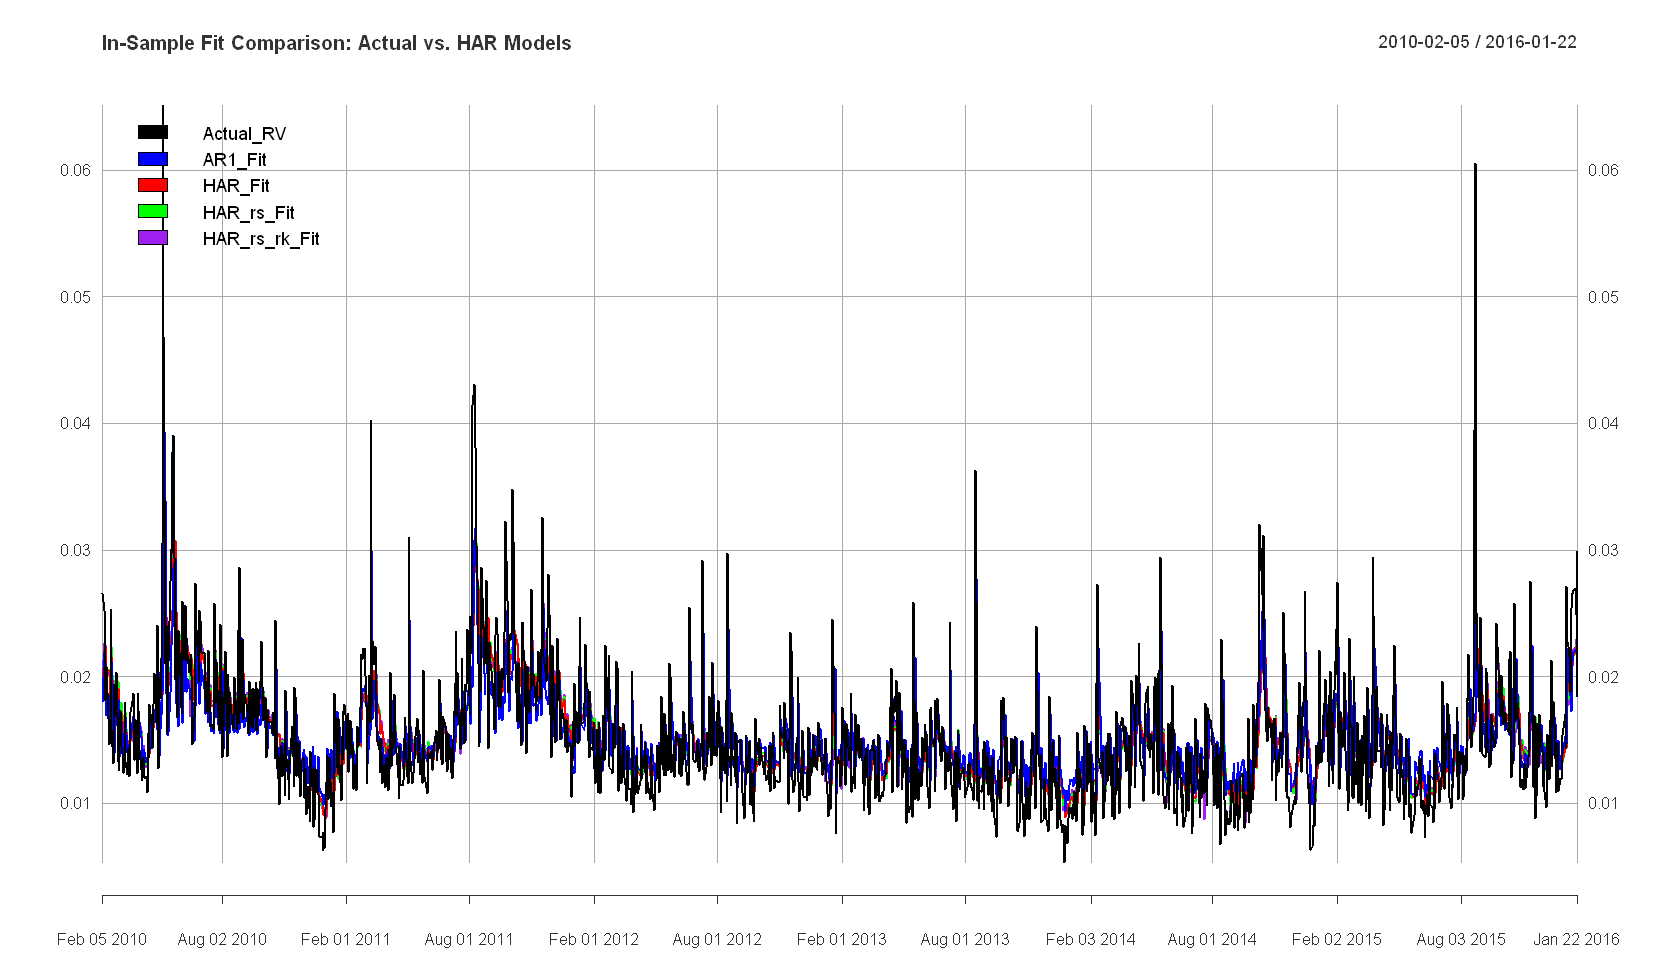

In [22]:
options(repr.plot.width = 14, repr.plot.height = 8)
plot.xts(na.omit(fit_comparison[, c("Actual_RV", "AR1_Fit", "HAR_Fit", "HAR_rs_Fit", "HAR_rs_rk_Fit")]), 
         screens = 1, # Plots them all on the same graph
         col = c("black", "blue", "red", "green", "purple"),
         main = "In-Sample Fit Comparison: Actual vs. HAR Models",
         legend.loc = "topleft")

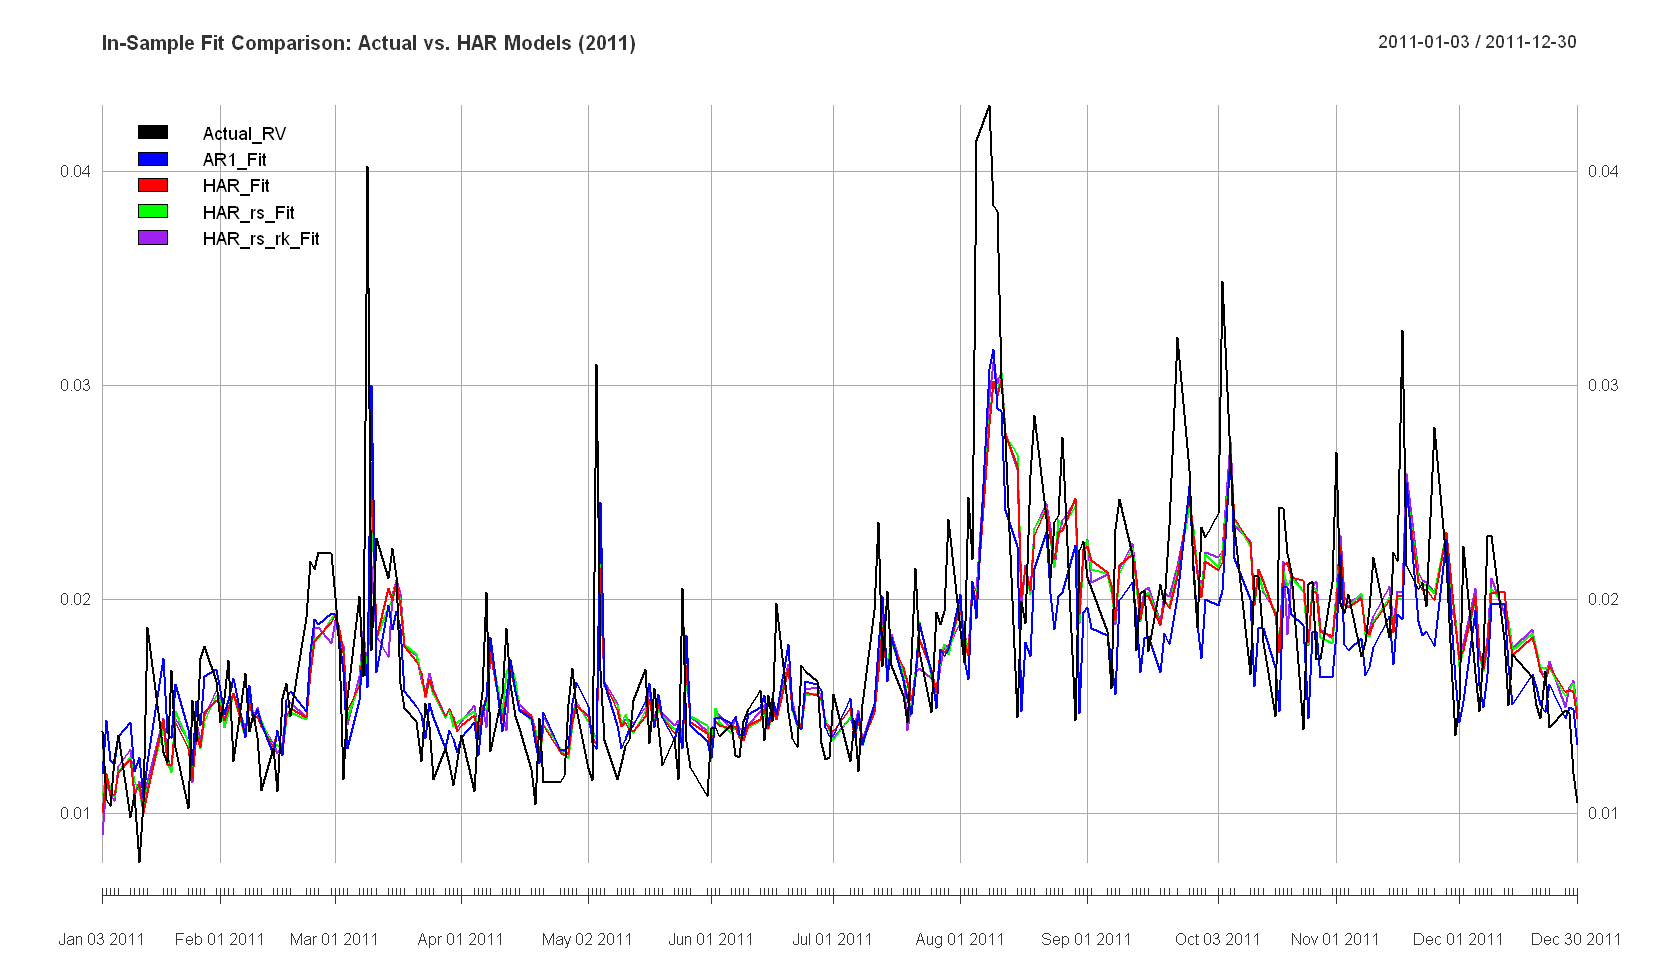

In [23]:
options(repr.plot.width = 14, repr.plot.height = 8)

#zoom in on 2011 for example
plot.xts(na.omit(fit_comparison["2011", c("Actual_RV", "AR1_Fit", "HAR_Fit", "HAR_rs_Fit", "HAR_rs_rk_Fit")]), 
         screens = 1, 
         col = c("black", "blue", "red", "green", "purple"),
         main = "In-Sample Fit Comparison: Actual vs. HAR Models (2011)",
         legend.loc = "topleft")

The set of plots above compares the actual realized volatility (Actual_RV) against the fitted values from the Heterogeneous Autoregressive (HAR) family of models, both over the full sample (2010–2016) and a magnified view of a highly volatile year (2011). Visually, all models in the HAR family—including the base AR(1), standard HAR, HAR_rs, and HAR_rs_rk—track the general contour of the actual volatility remarkably closely. They successfully capture the persistence and mean-reverting nature of the series. However, a closer look at the 2011 zoomed-in plot reveals that while these models adapt quickly to shifting volatility regimes, they systematically under-predict the extreme, sudden spikes in volatility. Furthermore, the fitted lines for the different HAR extensions are tightly clustered together. This indicates that while adding realized semivariance (rs) and realized kurtosis (rk) may improve statistical criteria, the visual difference in their in-sample fit is marginal compared to the baseline HAR model.

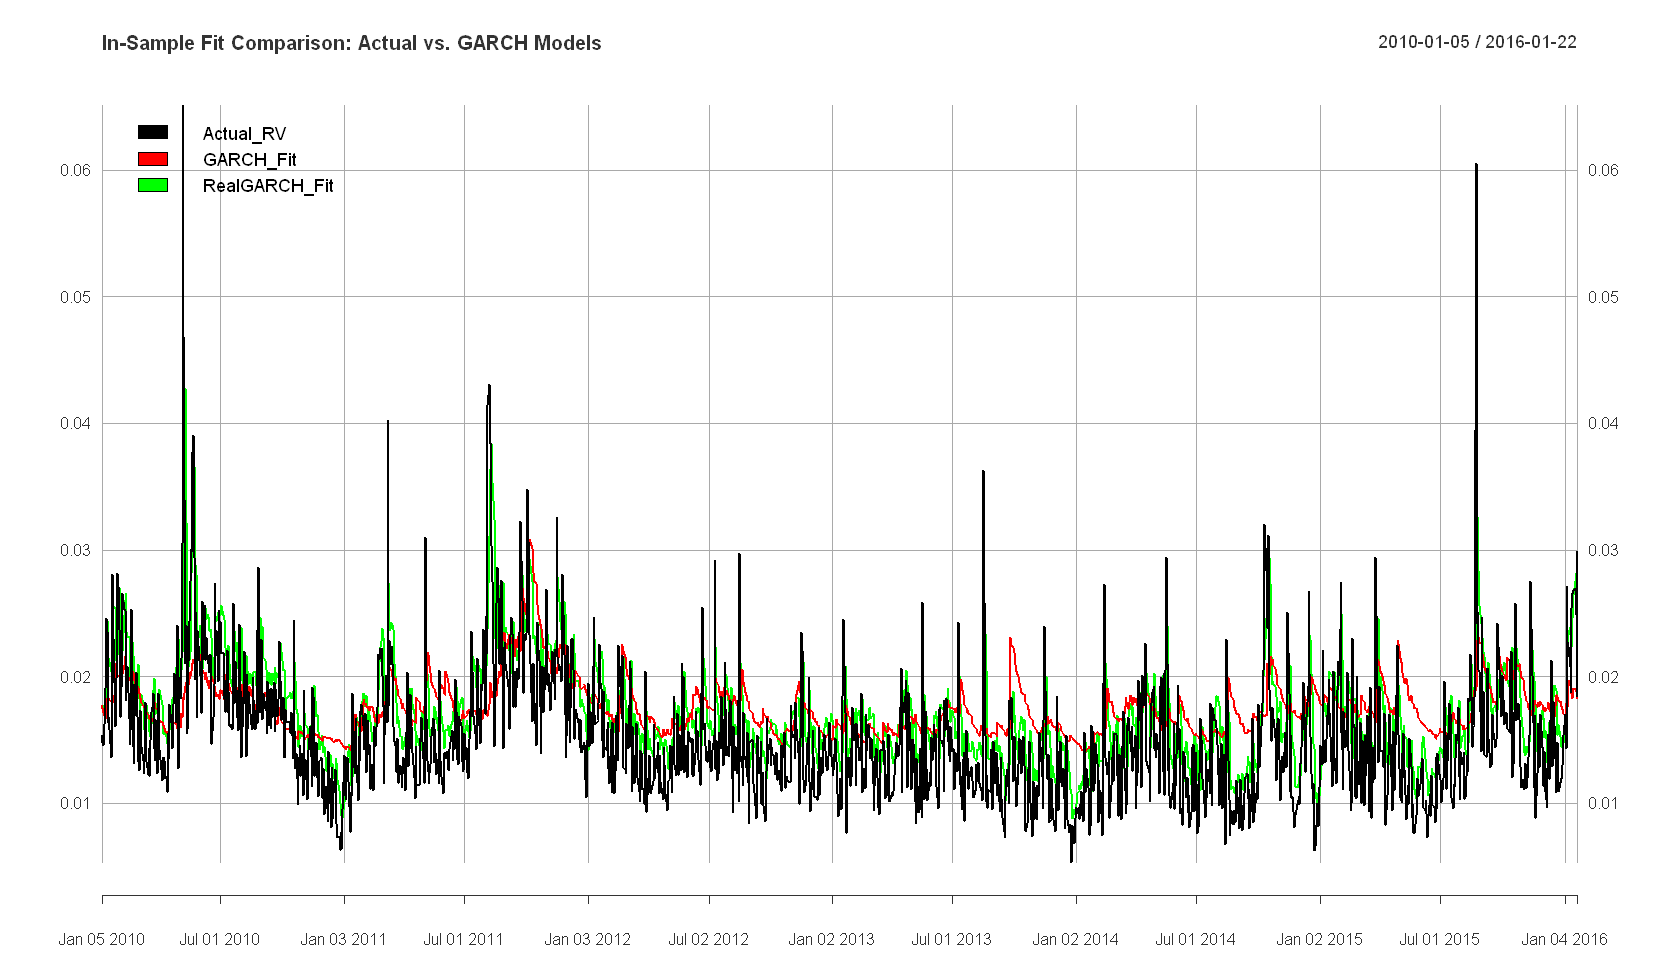

In [24]:
options(repr.plot.width = 14, repr.plot.height = 8)
plot.xts(na.omit(fit_comparison[, c("Actual_RV", "GARCH_Fit", "RealGARCH_Fit")]), 
         screens = 1, # Plots them all on the same graph
         col = c("black", "red", "green"),
         main = "In-Sample Fit Comparison: Actual vs. GARCH Models",
         legend.loc = "topleft")

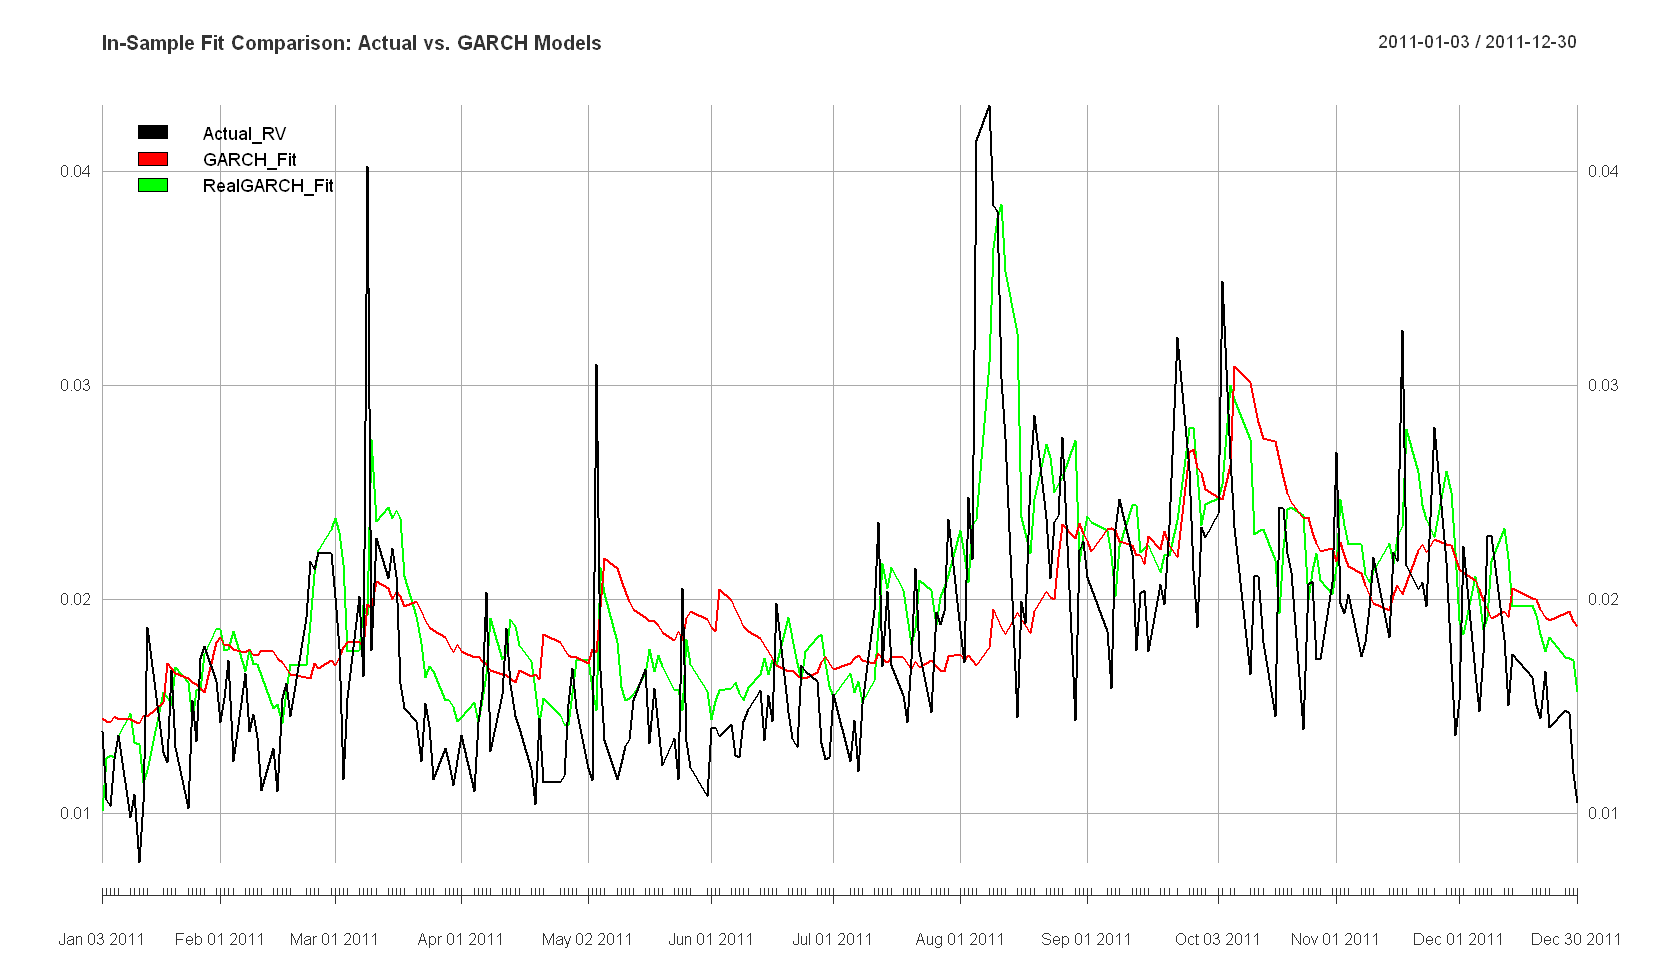

In [25]:
options(repr.plot.width = 14, repr.plot.height = 8)
plot.xts(na.omit(fit_comparison["2011", c("Actual_RV", "GARCH_Fit", "RealGARCH_Fit")]), 
         screens = 1, # Plots them all on the same graph
         col = c("black", "red", "green"),
         main = "In-Sample Fit Comparison: Actual vs. GARCH Models",
         legend.loc = "topleft")

The second set of plots highlights the stark contrast between traditional return-based volatility models and those that incorporate high-frequency data. The standard GARCH model (GARCH_Fit) produces a visibly sluggish and overly smoothed fitted line. It struggles to react immediately to sudden market shocks, often taking longer to peak and subsequently overestimating volatility during the recovery periods due to its high persistence. Conversely, the Realized GARCH model (RealGARCH_Fit) demonstrates vastly superior responsiveness. While it outperform the GARCH_Fit it strugges to track RV as closely as the afromentioned HAR models, as it is predicting above the RV line for most of the sample. However one key feature that can be seen in the 2011 subsample is the better tracking of large volatility spikes than the HAR family. All in all the lagged nature and slower reverting of GARCH model family can be clearly visible.

## Forecasts

In [26]:
window_len <- 750
n_obs <- nrow(har_data)
out_sample_len <- n_obs - window_len

In [27]:
fcst_ar1_roll <- numeric(out_sample_len)
fcst_har_roll <- numeric(out_sample_len)
fcst_har_rs_roll <- numeric(out_sample_len)
fcst_har_rs_rk_roll <- numeric(out_sample_len)

fcst_ar1_exp <- numeric(out_sample_len)
fcst_har_exp <- numeric(out_sample_len)
fcst_har_rs_exp <- numeric(out_sample_len)
fcst_har_rs_rk_exp <- numeric(out_sample_len)

# Actual values for the out-of-sample period to compare against
actual_out_sample <- har_data$RV[(window_len + 1):n_obs]

In [28]:
for (i in 1:out_sample_len) {
  
  # Rolling Window 
  train_data_roll <- har_data[i:(window_len + i - 1), ]
  
  # Expanding Window 
  train_data_exp <- har_data[1:(window_len + i - 1), ]
  
  # The row of data we are using to predict tomorrow's RV
  test_data <- har_data[(window_len + i), ]
  
  # --- ROLLING WINDOW FITS & FORECASTS ---
  fit_ar1_roll <- lm(RV ~ RV_1, data = train_data_roll)
  fit_har_roll <- lm(RV ~ RV_1 + RV_5 + RV_22, data = train_data_roll)
  fit_har_rs_roll <- lm(RV ~ RV_1 + RV_5 + RV_22 + RS_1, data = train_data_roll)
  fit_har_rs_rk_roll <- lm(RV ~ RV_1 + RV_5 + RV_22 + RS_1 + RK_1, data = train_data_roll)
    
  fcst_ar1_roll[i] <- predict(fit_ar1_roll, newdata = test_data)
  fcst_har_roll[i] <- predict(fit_har_roll, newdata = test_data)
  fcst_har_rs_roll[i] <- predict(fit_har_rs_roll, newdata = test_data)  
  fcst_har_rs_rk_roll[i] <- predict(fit_har_rs_rk_roll, newdata = test_data) 
    
  # --- EXPANDING WINDOW FITS & FORECASTS ---
  fit_ar1_exp <- lm(RV ~ RV_1, data = train_data_exp)
  fit_har_exp <- lm(RV ~ RV_1 + RV_5 + RV_22, data = train_data_exp)
  fit_har_rs_exp <- lm(RV ~ RV_1 + RV_5 + RV_22 + RS_1, data = train_data_exp)
  fit_har_rs_rk_exp <- lm(RV ~ RV_1 + RV_5 + RV_22 + RS_1 + RK_1, data = train_data_exp)
    
  fcst_ar1_exp[i] <- predict(fit_ar1_exp, newdata = test_data)
  fcst_har_exp[i] <- predict(fit_har_exp, newdata = test_data)
  fcst_har_rs_exp[i] <- predict(fit_har_rs_exp, newdata = test_data)  
  fcst_har_rs_rk_exp[i] <- predict(fit_har_rs_rk_exp, newdata = test_data)   
}

In [29]:
# Helper function to calculate MSE and MAE
calc_loss <- function(actual, forecast) {
  error <- actual - forecast
  mse <- mean(error^2, na.rm = TRUE)
  mae <- mean(abs(error), na.rm = TRUE)
  return(c(MSE = mse, MAE = mae))
}

In [30]:
results_matrix <- rbind(
  calc_loss(actual_out_sample, fcst_ar1_roll),
  calc_loss(actual_out_sample, fcst_har_roll),
  calc_loss(actual_out_sample, fcst_har_rs_roll),
  calc_loss(actual_out_sample, fcst_har_rs_rk_roll),
  calc_loss(actual_out_sample, fcst_ar1_exp),
  calc_loss(actual_out_sample, fcst_har_exp),
  calc_loss(actual_out_sample, fcst_har_rs_exp),
  calc_loss(actual_out_sample, fcst_har_rs_rk_exp)
)

rownames(results_matrix) <- c(
  "AR1 (Roll)", "HAR (Roll)", "HAR-RS (Roll)", "HAR-RS-RK (Roll)",
  "AR1 (Exp)", "HAR (Exp)", "HAR-RS (Exp)", "HAR-RS-RK (Exp)"
)

In [31]:
cat("--- OUT-OF-SAMPLE FORECAST EVALUATION ---\n")
print(round(results_matrix, 7))

--- OUT-OF-SAMPLE FORECAST EVALUATION ---
                      MSE       MAE
AR1 (Roll)       1.72e-05 0.0028961
HAR (Roll)       1.60e-05 0.0027697
HAR-RS (Roll)    1.60e-05 0.0027680
HAR-RS-RK (Roll) 1.57e-05 0.0027614
AR1 (Exp)        1.72e-05 0.0029373
HAR (Exp)        1.58e-05 0.0027763
HAR-RS (Exp)     1.57e-05 0.0027720
HAR-RS-RK (Exp)  1.54e-05 0.0027632


Errors show again the superiority of HAR family compared to the simple AR1 and furthermore the similarity within the HAR family of models. Moreover, the expanding window out-of-sample forecasts yield slightly lower MSE across all HAR models, but MAE is showing opposite patern, all in all the errors are basically identical and extremely small, so it is inconclusive to say which technique is better in this case. The model with lowest errors is the HAR model with realized skewness and kurtosis variables. Next section shows the visual errors across time for all models

In [32]:
err_ar1_roll       <- actual_out_sample - fcst_ar1_roll
err_har_roll       <- actual_out_sample - fcst_har_roll
err_har_rs_roll    <- actual_out_sample - fcst_har_rs_roll
err_har_rs_rk_roll <- actual_out_sample - fcst_har_rs_rk_roll
err_ar1_exp       <- actual_out_sample - fcst_ar1_exp
err_har_exp       <- actual_out_sample - fcst_har_exp
err_har_rs_exp    <- actual_out_sample - fcst_har_rs_exp
err_har_rs_rk_exp <- actual_out_sample - fcst_har_rs_rk_exp

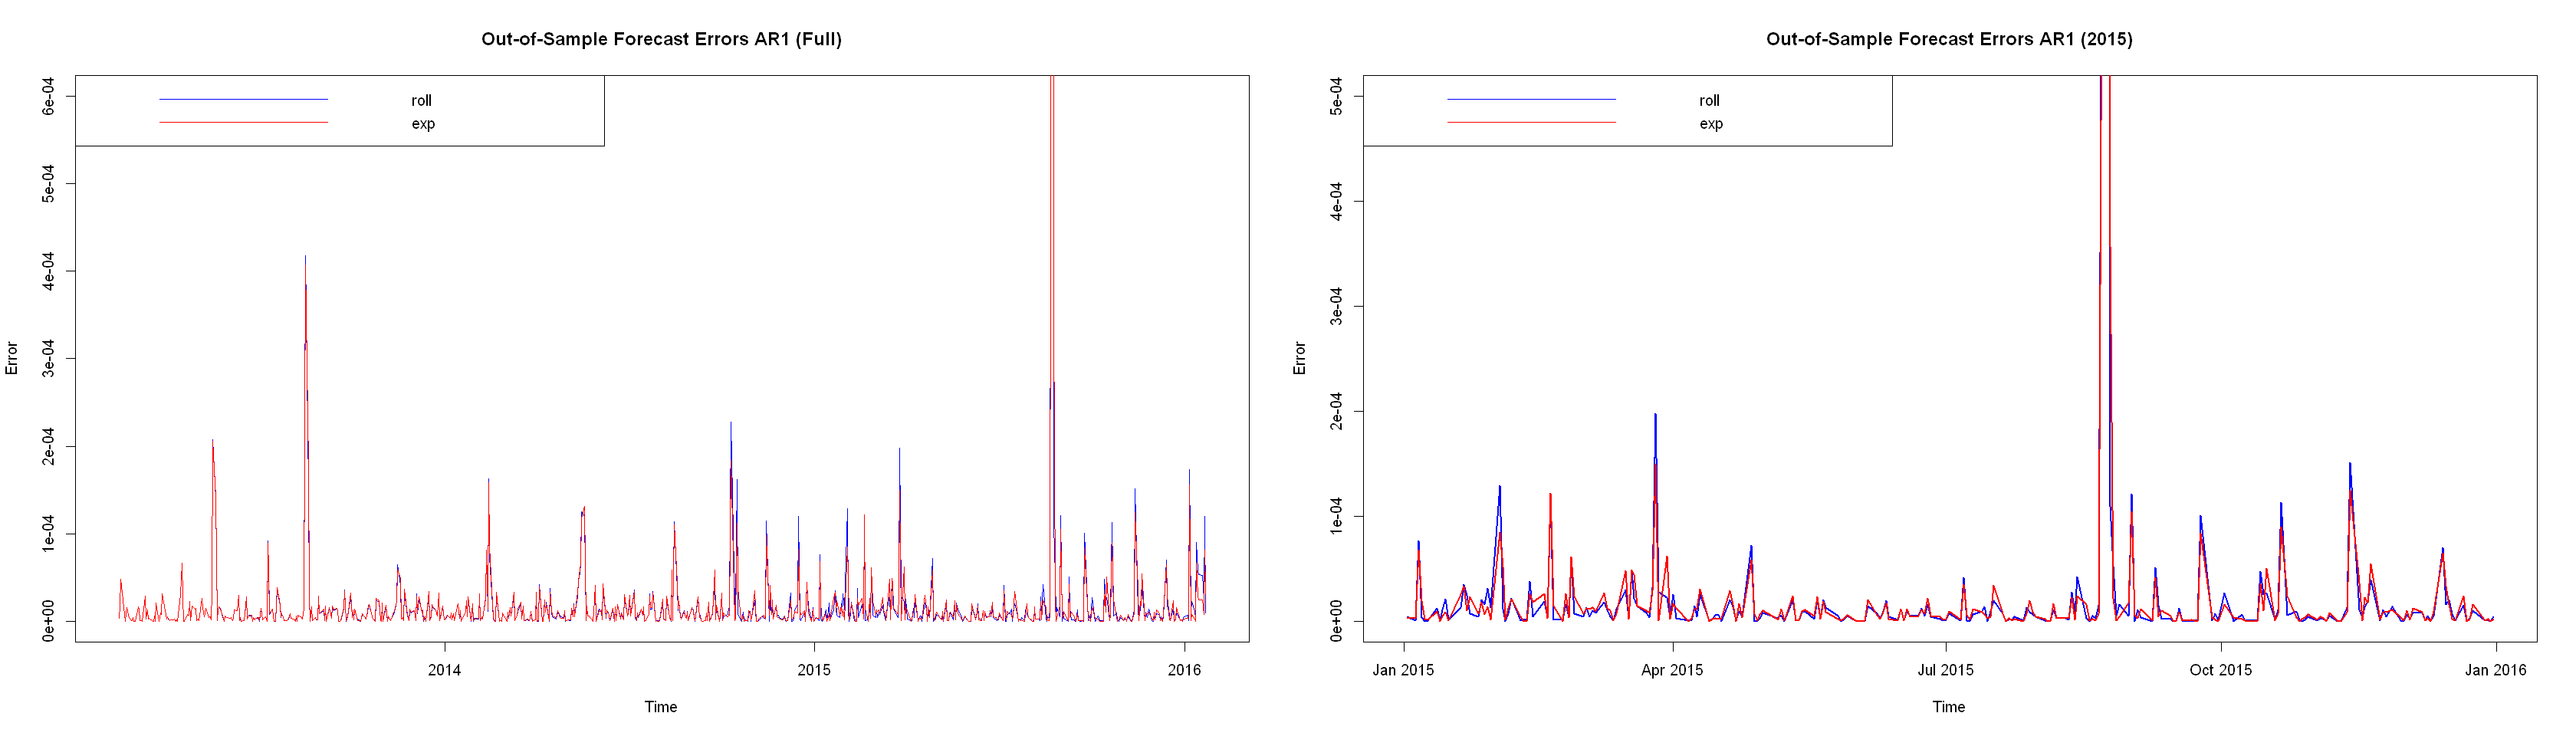

In [53]:
options(repr.plot.width = 28, repr.plot.height = 8)
  
# 1. Prepare your data
ar1_errors <- merge(err_ar1_roll, err_ar1_exp)
ar1_errors_2015 <- ar1_errors["2015"] # Create the 2014 subset
  
# 2. Split the plotting window into 1 row, 2 columns
par(mfrow = c(1, 2))
  
# 3. Plot 1: Full dataset (Left Side)
zoo::plot.zoo(ar1_errors^2, plot.type = "single", 
            col = c("blue", "red"),lwd = 1.5,ylim = c(0, 0.0006),
            main = "Out-of-Sample Forecast Errors AR1 (Full)", 
            ylab = "Error", xlab = "Time")
legend("topleft", legend = c("roll", "exp"), 
        col = c("blue", "red"), lty = 1)
  
# 4. Plot 2: 2014 dataset only (Right Side)
zoo::plot.zoo(ar1_errors_2015^2, plot.type = "single", 
            col = c("blue", "red"),lwd = 2,ylim = c(0, 0.0005),
            main = "Out-of-Sample Forecast Errors AR1 (2015)", 
            ylab = "Error", xlab = "Time")
legend("topleft", legend = c("roll", "exp"), 
        col = c("blue", "red"), lty = 1)

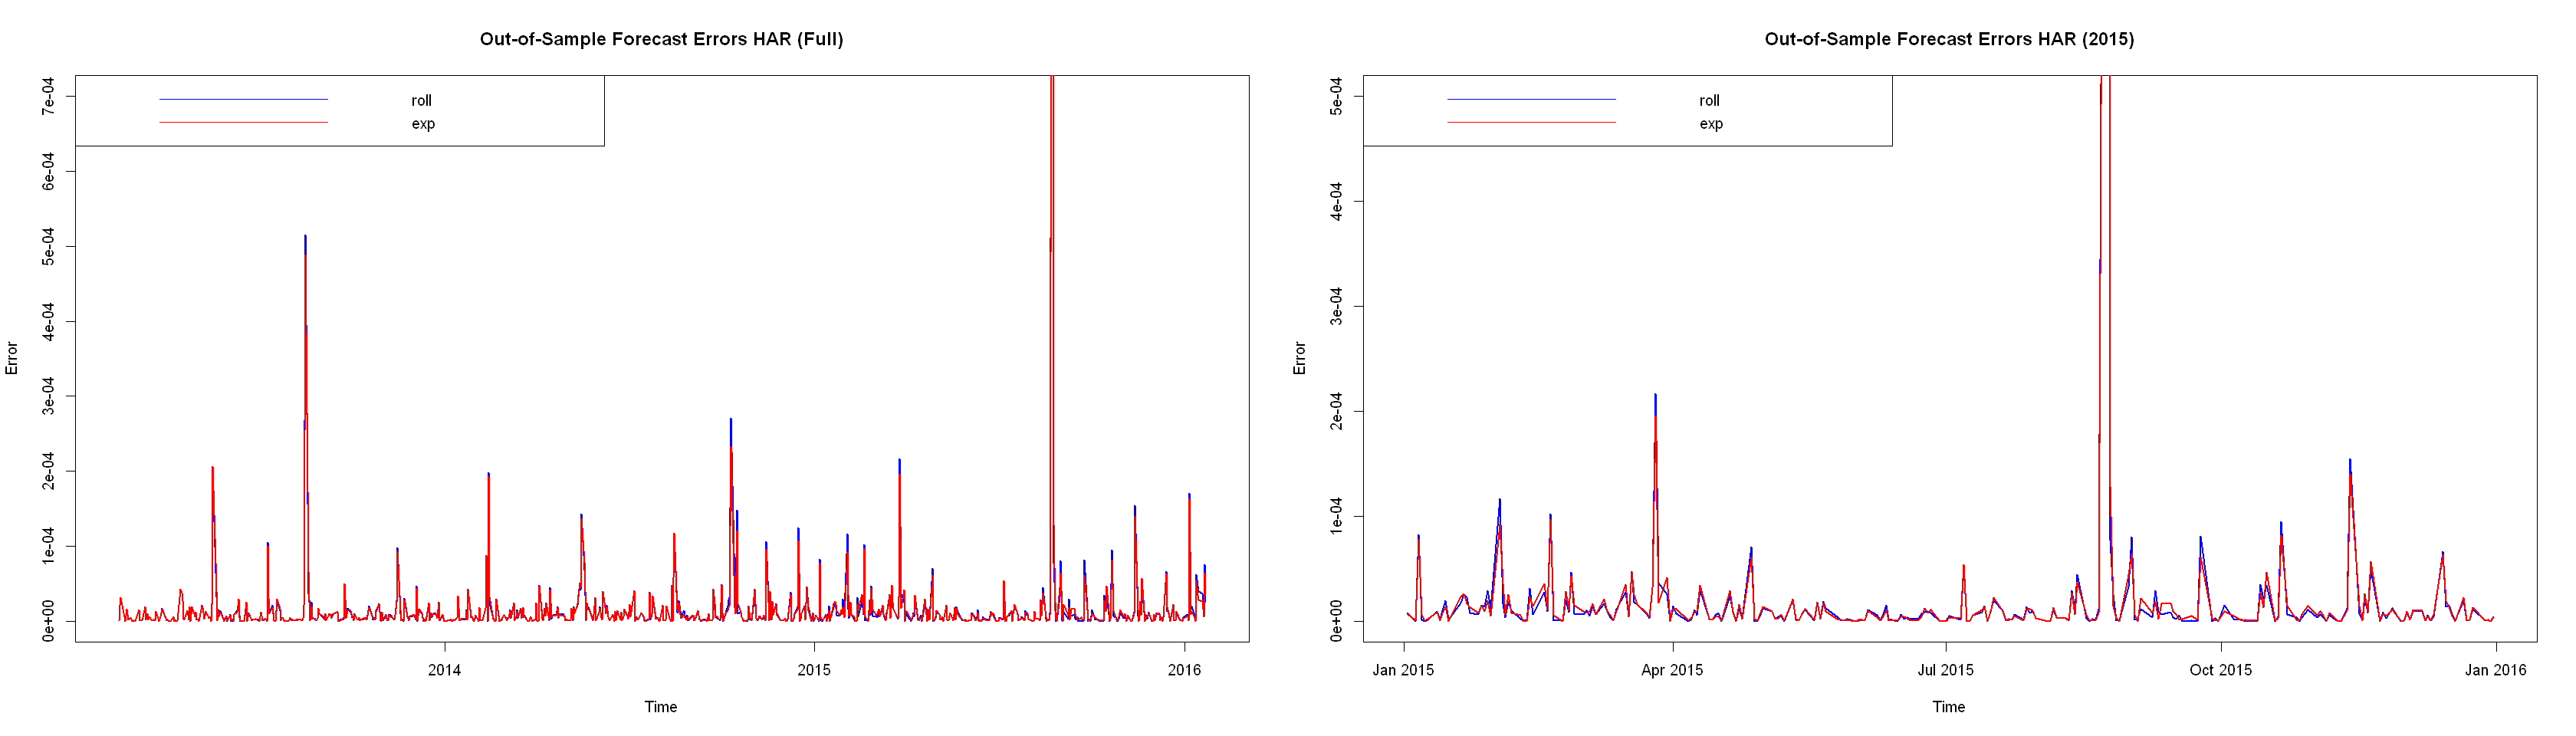

In [41]:
options(repr.plot.width = 28, repr.plot.height = 8)
  
# 1. Prepare your data
har_errors <- merge(err_har_roll, err_har_exp)
har_errors_2015 <- har_errors["2015"] # Create the 2014 subset
  
# 2. Split the plotting window into 1 row, 2 columns
par(mfrow = c(1, 2))
  
# 3. Plot 1: Full dataset (Left Side)
zoo::plot.zoo(har_errors^2, plot.type = "single", 
            col = c("blue", "red"),lwd = 2,ylim = c(0, 0.0007),
            main = "Out-of-Sample Forecast Errors HAR (Full)", 
            ylab = "Error", xlab = "Time")
legend("topleft", legend = c("roll", "exp"), 
        col = c("blue", "red"), lty = 1)
  
# 4. Plot 2: 2014 dataset only (Right Side)
zoo::plot.zoo(har_errors_2015^2, plot.type = "single", 
            col = c("blue", "red"),lwd = 2,ylim = c(0, 0.0005),
            main = "Out-of-Sample Forecast Errors HAR (2015)", 
            ylab = "Error", xlab = "Time")
legend("topleft", legend = c("roll", "exp"), 
        col = c("blue", "red"), lty = 1)

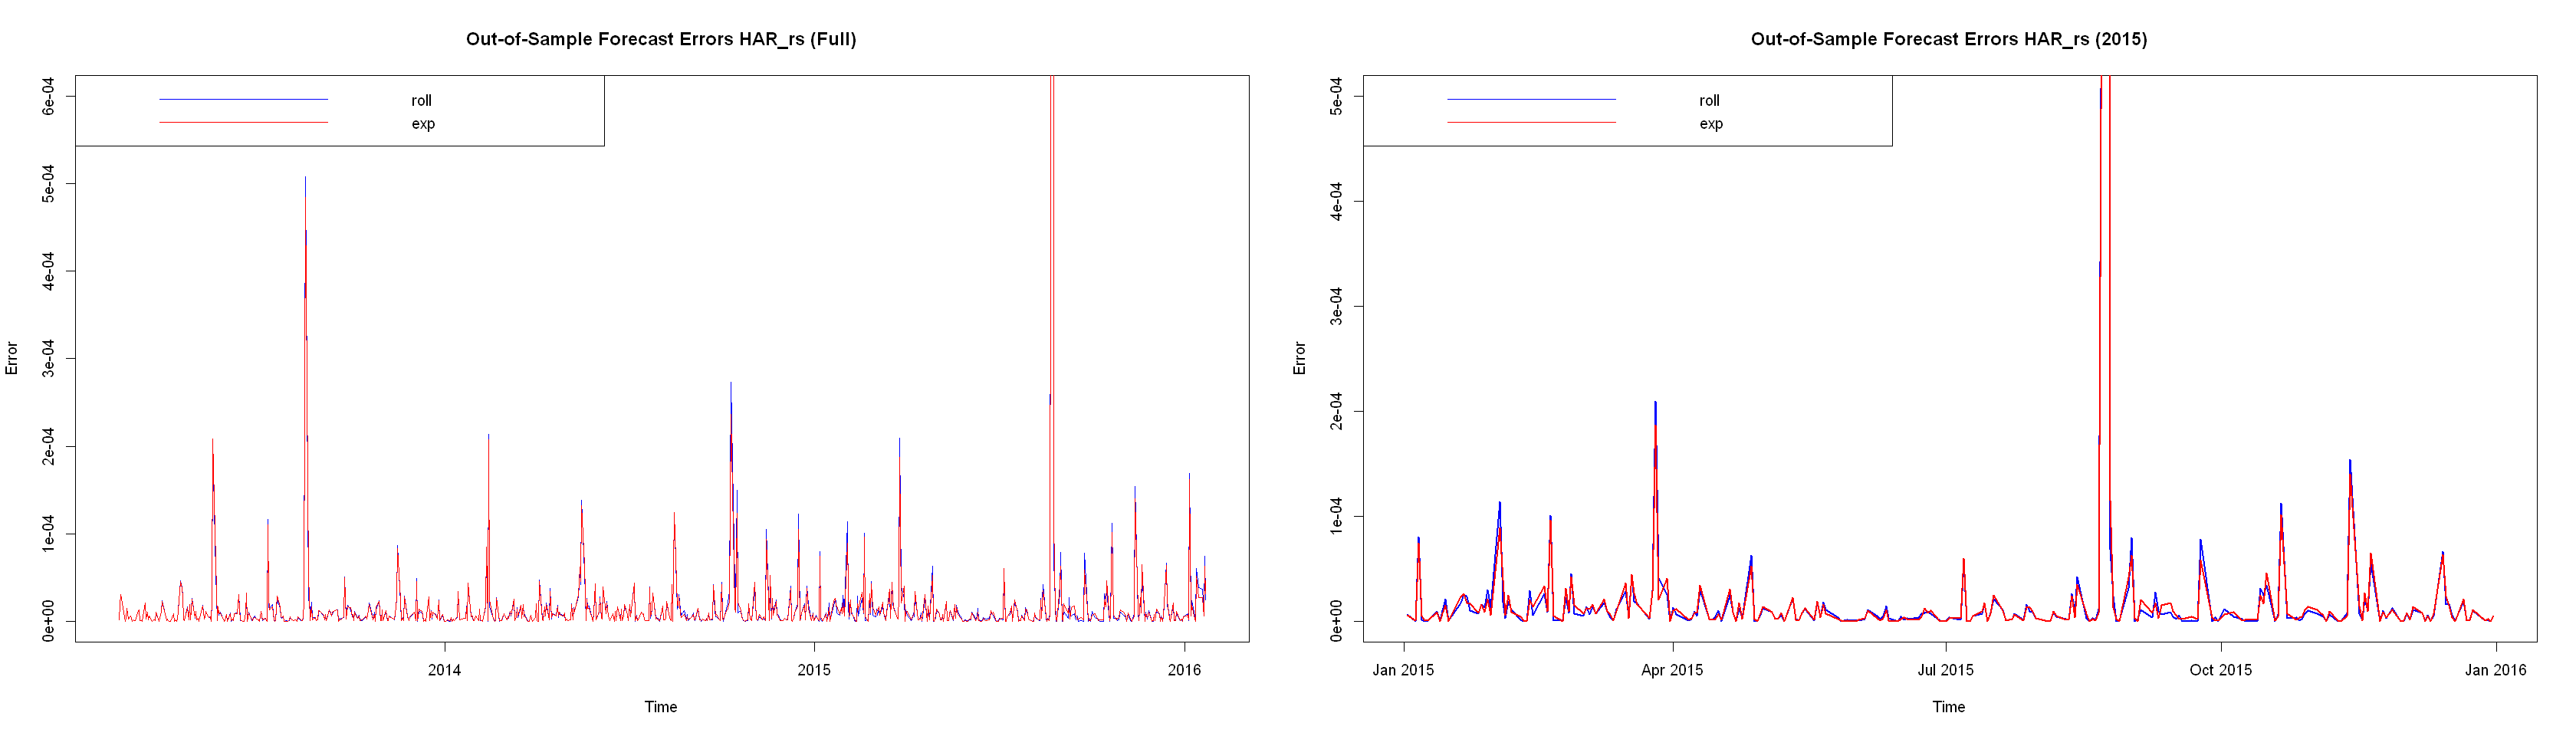

In [43]:
options(repr.plot.width = 28, repr.plot.height = 8)
 
# 1. Prepare your data
har_rs_errors <- merge(err_har_rs_roll, err_har_rs_exp)
har_rs_errors_2015 <- har_rs_errors["2015"] # Create the 2014 subset
  
# 2. Split the plotting window into 1 row, 2 columns
par(mfrow = c(1, 2))
  
# 3. Plot 1: Full dataset (Left Side)
zoo::plot.zoo(har_rs_errors^2, plot.type = "single", 
            col = c("blue", "red"),lwd = 1.5,ylim = c(0, 0.0006),
            main = "Out-of-Sample Forecast Errors HAR_rs (Full)", 
            ylab = "Error", xlab = "Time")
legend("topleft", legend = c("roll", "exp"), 
        col = c("blue", "red"), lty = 1)
  
# 4. Plot 2: 2014 dataset only (Right Side)
zoo::plot.zoo(har_rs_errors_2015^2, plot.type = "single", 
            col = c("blue", "red"),lwd = 2,ylim = c(0, 0.0005),
            main = "Out-of-Sample Forecast Errors HAR_rs (2015)", 
            ylab = "Error", xlab = "Time")
legend("topleft", legend = c("roll", "exp"), 
        col = c("blue", "red"), lty = 1,bg = adjustcolor("white", alpha.f = 0.7))

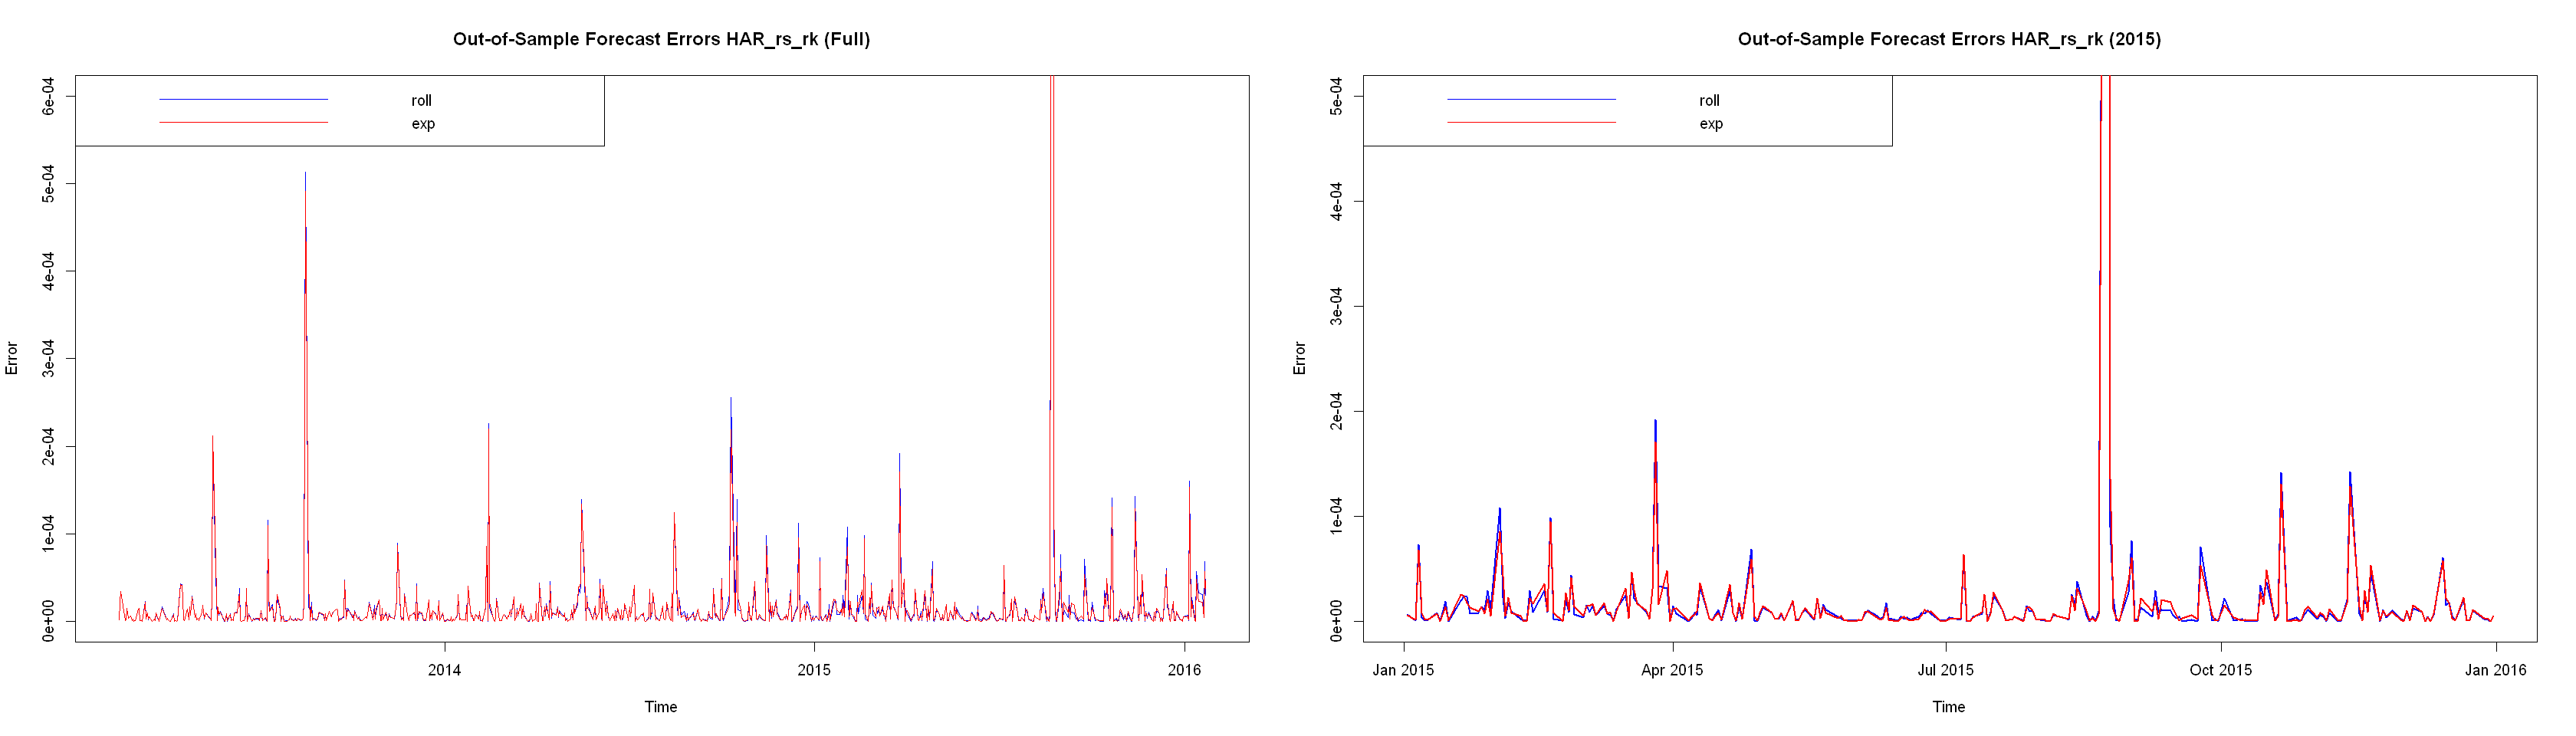

In [45]:
options(repr.plot.width = 28, repr.plot.height = 8)
 
# 1. Prepare your data
har_rs_rk_errors <- merge(err_har_rs_rk_roll, err_har_rs_rk_exp)
har_rs_rk_errors_2015 <- har_rs_rk_errors["2015"] # Create the 2014 subset
  
# 2. Split the plotting window into 1 row, 2 columns
par(mfrow = c(1, 2))
  
# 3. Plot 1: Full dataset (Left Side)
zoo::plot.zoo(har_rs_rk_errors^2, plot.type = "single", 
            col = c("blue", "red"),lwd = 1.5,ylim = c(0, 0.0006),
            main = "Out-of-Sample Forecast Errors HAR_rs_rk (Full)", 
            ylab = "Error", xlab = "Time")
legend("topleft", legend = c("roll", "exp"), 
        col = c("blue", "red"), lty = 1)
  
# 4. Plot 2: 2014 dataset only (Right Side)
zoo::plot.zoo(har_rs_rk_errors_2015^2, plot.type = "single", 
            col = c("blue", "red"),lwd = 2,ylim = c(0, 0.0005),
            main = "Out-of-Sample Forecast Errors HAR_rs_rk (2015)", 
            ylab = "Error", xlab = "Time")
legend("topleft", legend = c("roll", "exp"), 
        col = c("blue", "red"), lty = 1,bg = adjustcolor("white", alpha.f = 0.7))

In [47]:
all_errors_roll <- merge(err_ar1_roll, err_har_roll, err_har_rs_roll,err_har_rs_rk_roll)
all_errors_exp <- merge(err_ar1_exp, err_har_exp, err_har_rs_exp, err_har_rs_rk_exp)

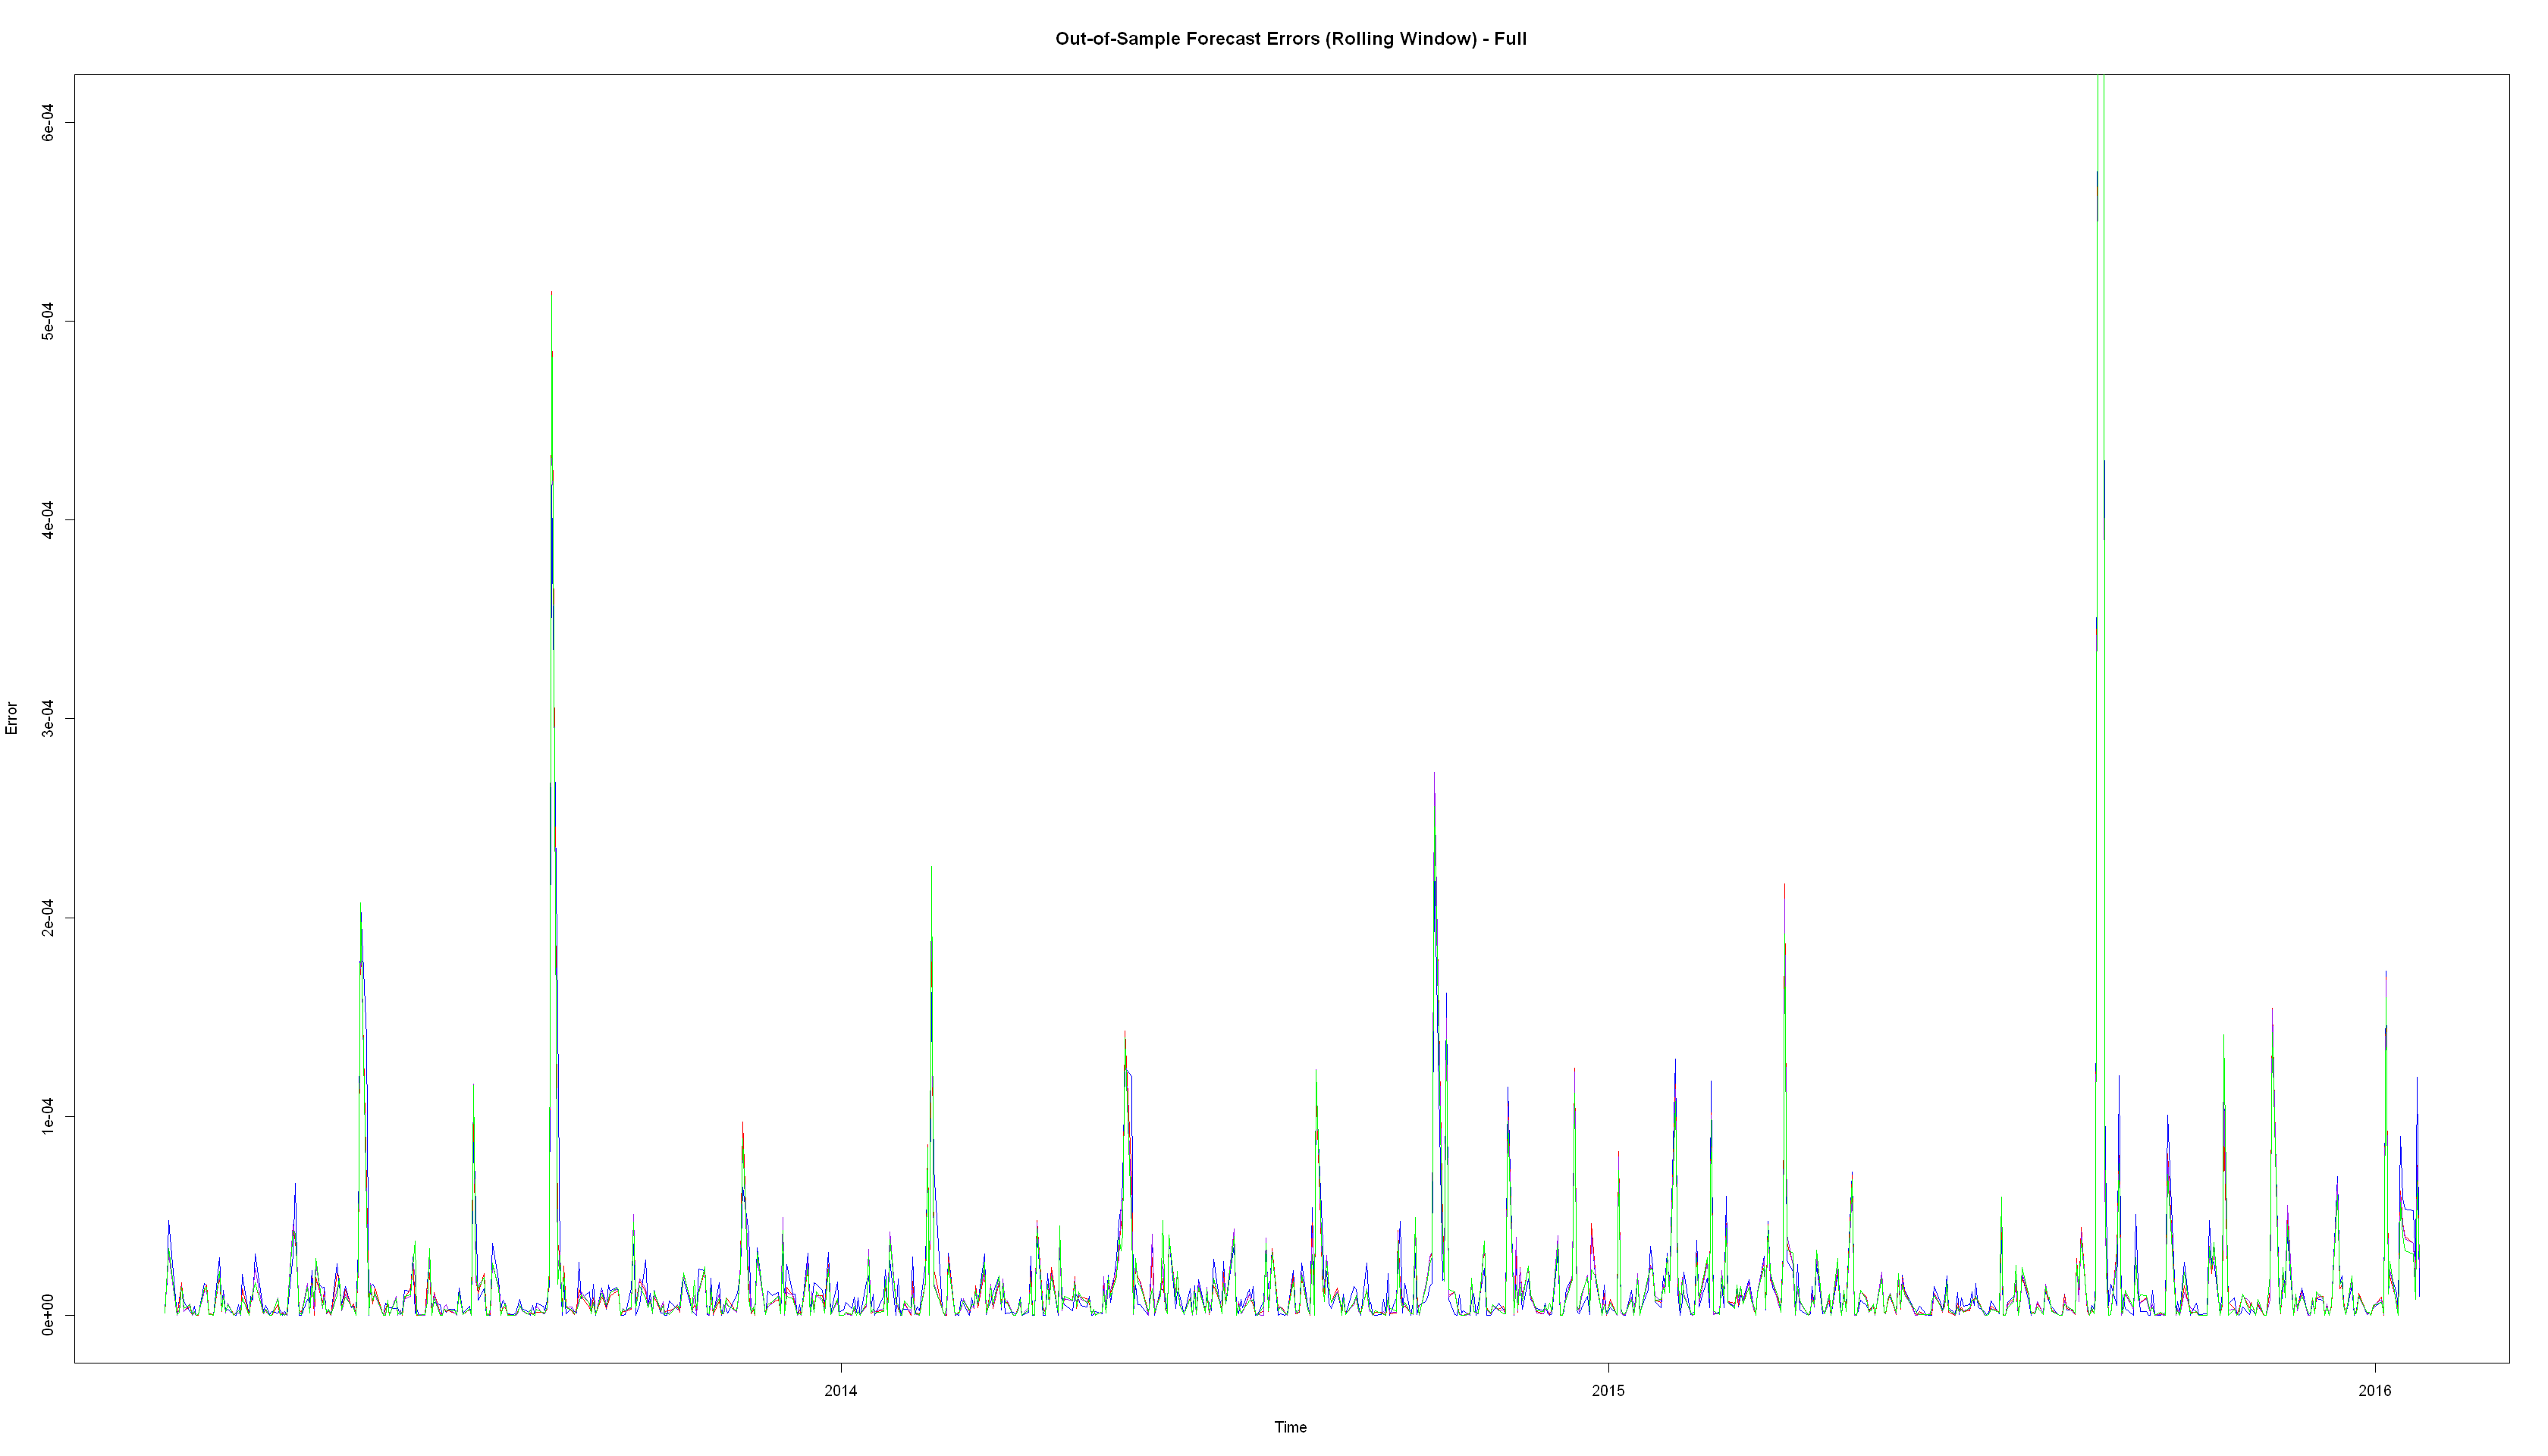

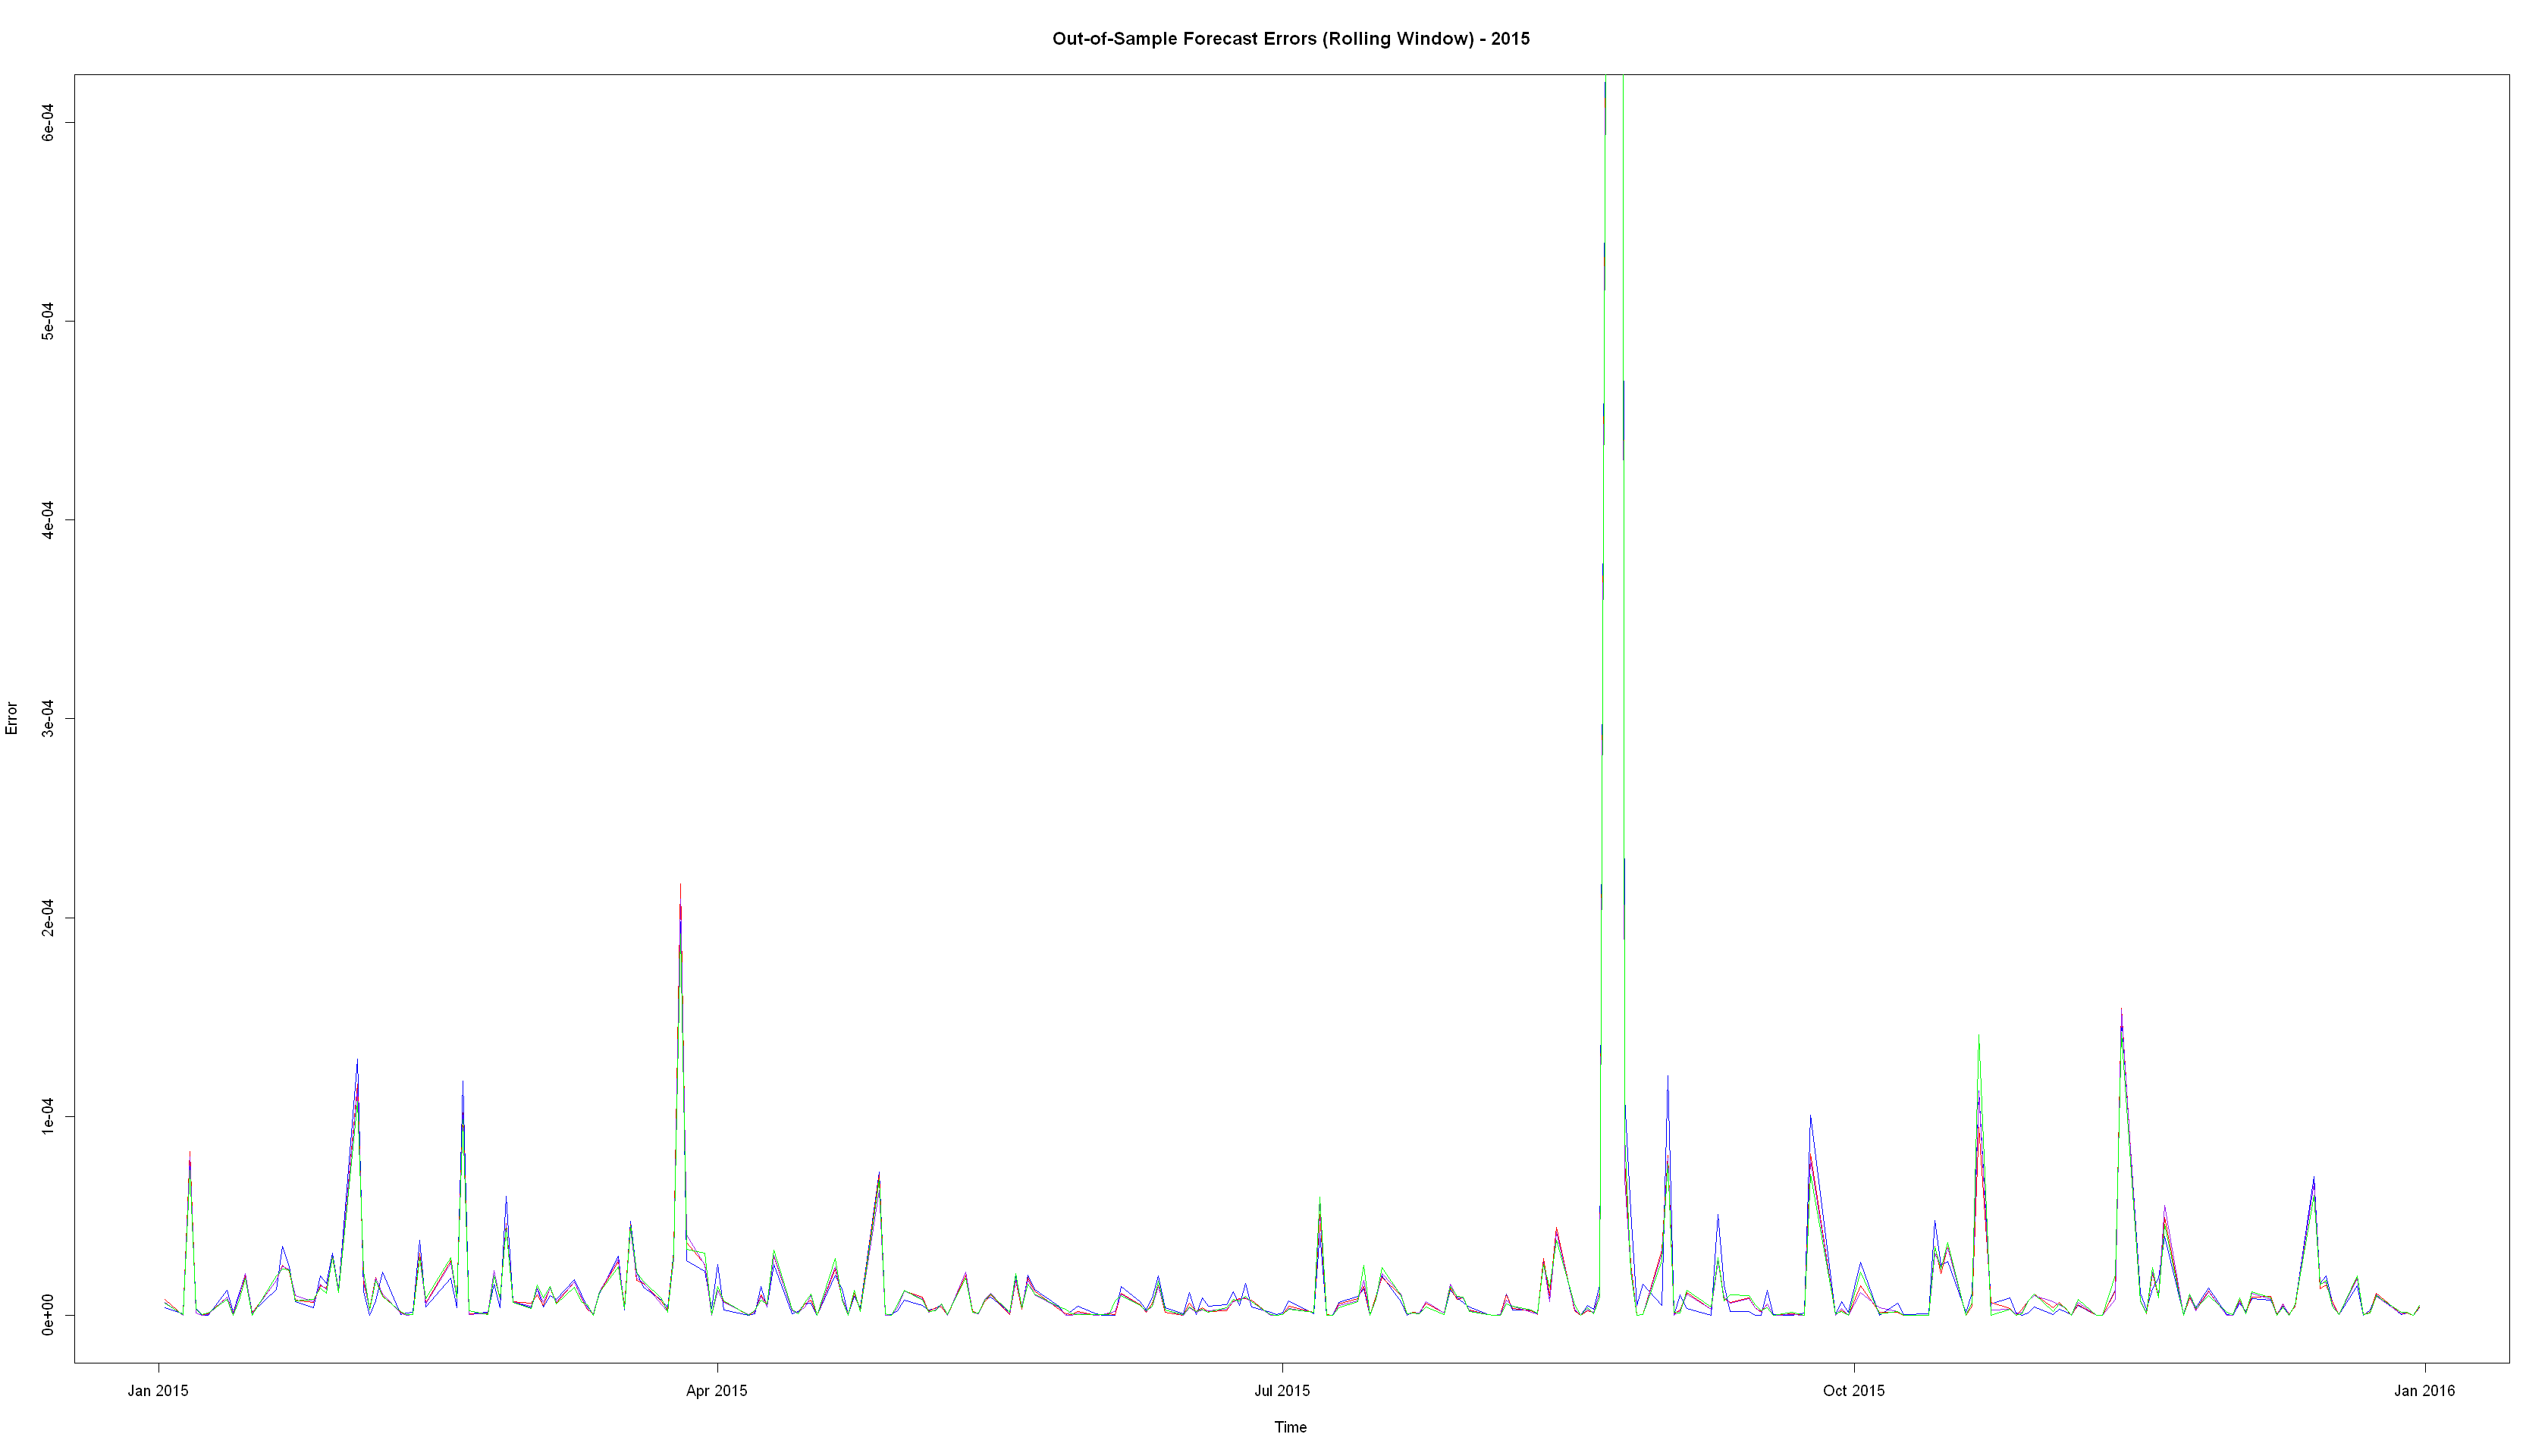

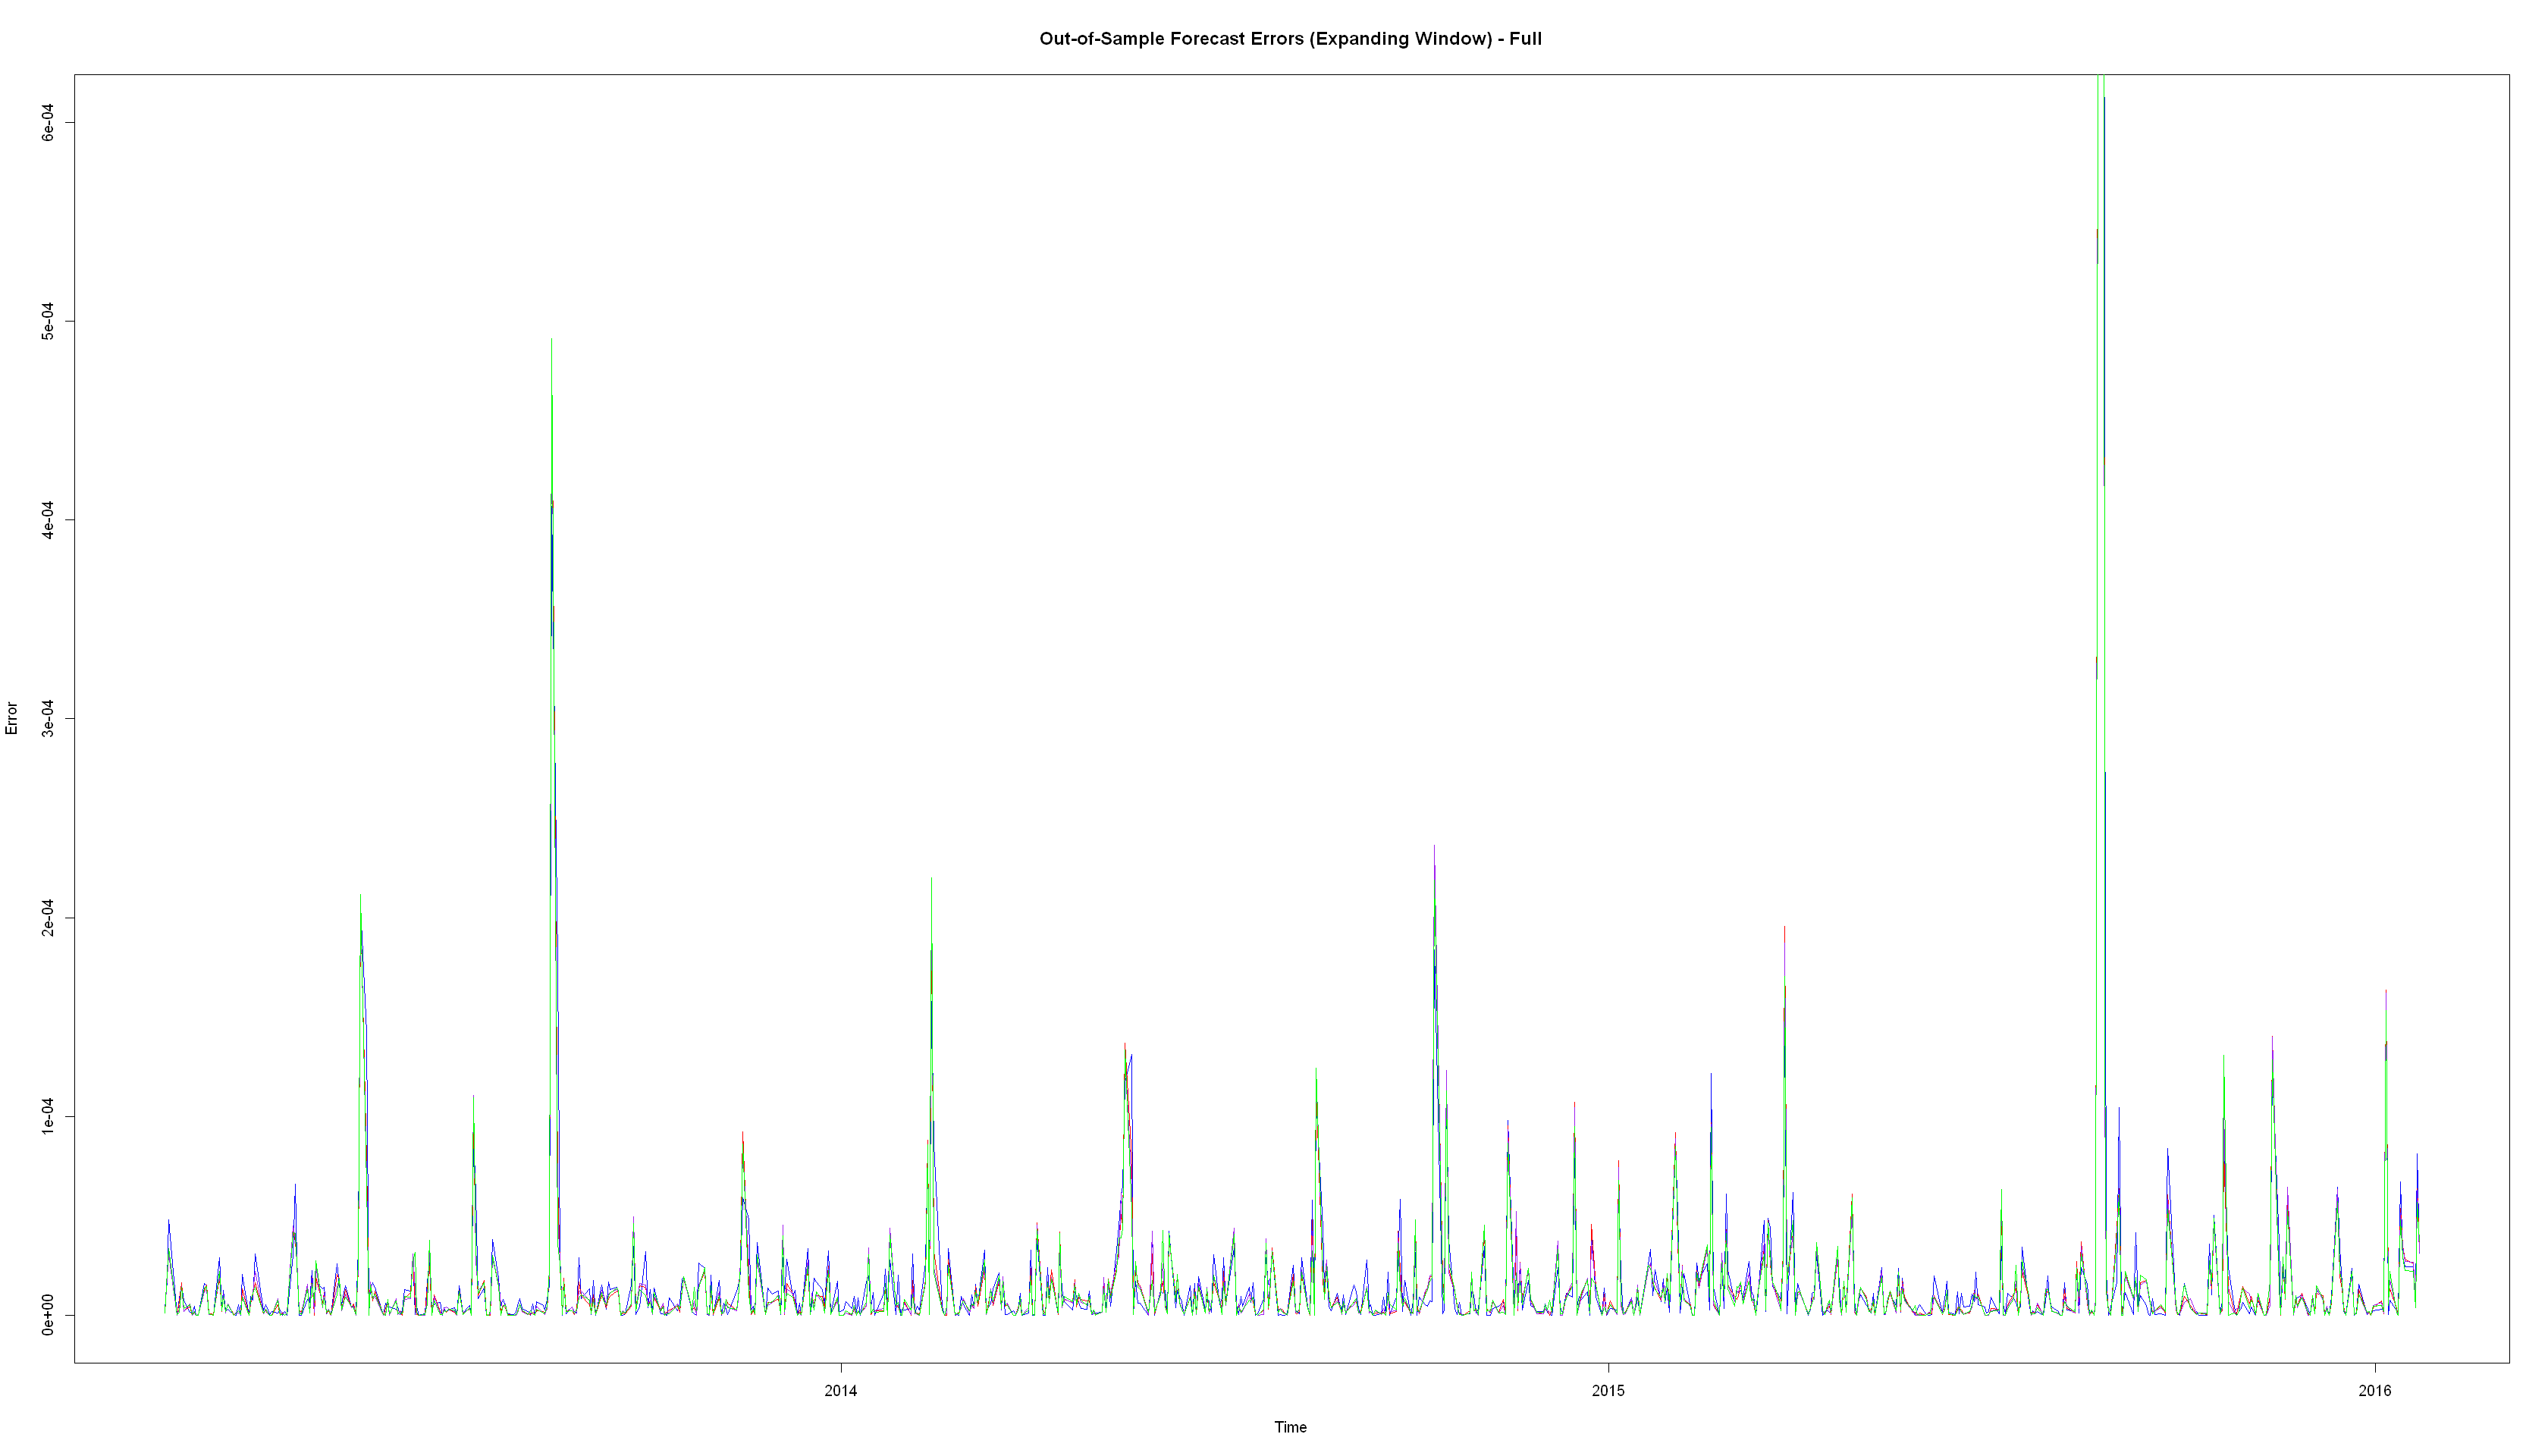

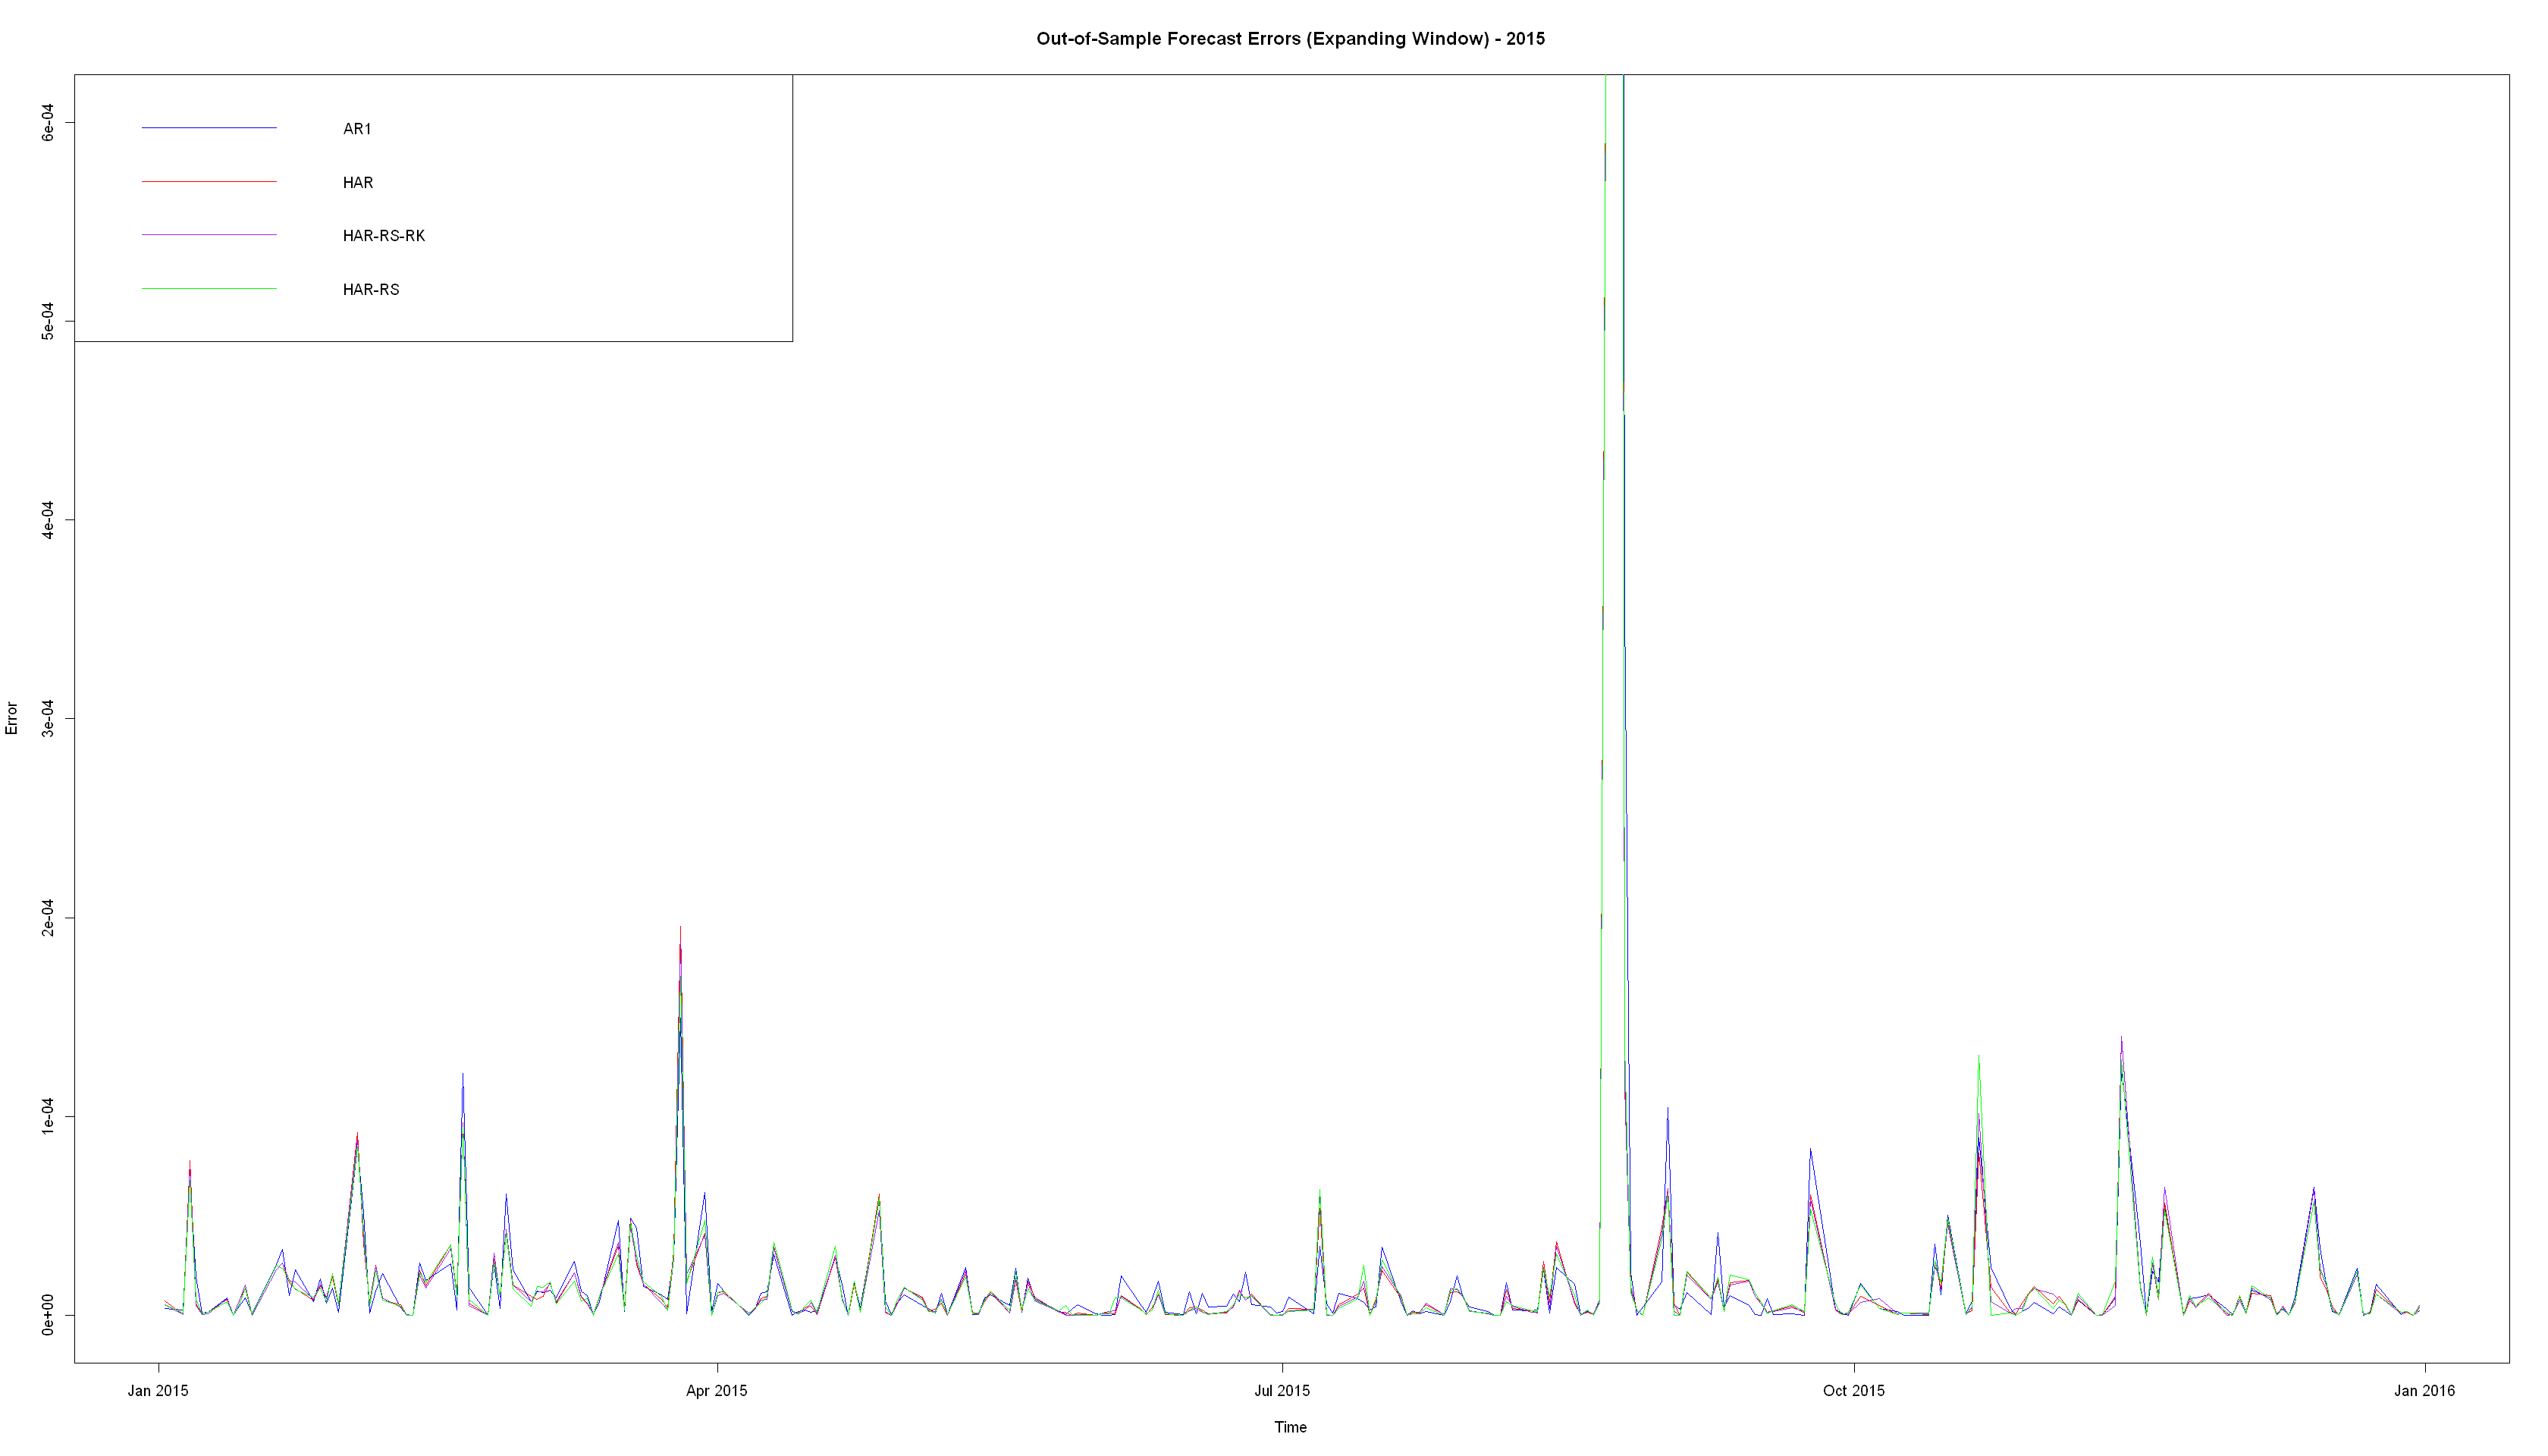

In [51]:
all_errors_roll_2015 <- all_errors_roll["2015"]
all_errors_exp_2015 <- all_errors_exp["2015"]
options(repr.plot.width = 28, repr.plot.height = 16)
# plot.zoo with plot.type="single" elegantly plots all columns at once
zoo::plot.zoo(all_errors_roll^2, plot.type = "single", 
            col = c("blue", "red", "purple", "green"),lwd=1.5,ylim = c(0, 0.0006),
            main = "Out-of-Sample Forecast Errors (Rolling Window) - Full", 
            ylab = "Error", xlab = "Time")

zoo::plot.zoo(all_errors_roll_2015^2, plot.type = "single", 
            col = c("blue", "red", "purple", "green"),lwd=1.5,ylim = c(0, 0.0006),
            main = "Out-of-Sample Forecast Errors (Rolling Window) - 2015", 
            ylab = "Error", xlab = "Time")

zoo::plot.zoo(all_errors_exp^2, plot.type = "single", 
            col = c("blue", "red", "purple", "green"),lwd=1.5,ylim = c(0, 0.0006),
            main = "Out-of-Sample Forecast Errors (Expanding Window) - Full", 
            ylab = "Error", xlab = "Time")

zoo::plot.zoo(all_errors_exp_2015^2, plot.type = "single", 
            col = c("blue", "red", "purple", "green"),lwd=1.5,ylim = c(0, 0.0006),
            main = "Out-of-Sample Forecast Errors (Expanding Window) - 2015", 
            ylab = "Error", xlab = "Time")
# Add the legend
legend("topleft", legend = c("AR1", "HAR", "HAR-RS-RK", "HAR-RS"), 
        col = c("blue", "red", "purple", "green"), lty = 1)


### Forecasting realized volatility with the Realized GARCH model

#### First attempt: `ugarchroll`

Our initial approach mirrored the standard GARCH forecasts: we used `rugarch`'s
convenience function `ugarchroll()`, which automatically slides the estimation
window across the out-of-sample period, re-estimates the model every
`refit.every` days, and collects all one-step-ahead forecasts in a single call.
This works without issue for the standard sGARCH model.

#### Why it failed for realGARCH

For the Realized GARCH model, `ugarchroll()` returned an **empty forecast set**:
the `@forecast$density` slot was `NULL`, which in turn caused a
`subscript out of bounds` error downstream when we tried to plot the (missing)
realGARCH column.

The cause is twofold:

1. **Estimation difficulty.** Realized GARCH augments the variance recursion
 with a *measurement equation* linking the realized measure to the latent
 conditional variance (extra parameters $\xi$, $\delta$, $\lambda$ and the
 leverage terms $\tau_1$, $\tau_2$). This likelihood is markedly harder to
 optimise than the plain GARCH likelihood, and on some estimation windows the
 optimiser cannot invert the Hessian (`rugarch-->warning: failed to invert
 hessian`), i.e. it fails to certify convergence.

2. **All-or-nothing behaviour of `ugarchroll`.** When *any single* refit window
 fails to converge, `ugarchroll()` discards the *entire* set of forecasts
 rather than just the offending window. With ~150 refit windows over the
 out-of-sample period, one problematic window is enough to wipe out all 750
 forecasts. Changing the solver, scaling, or jittering the data did not make
 `ugarchroll` reliable here.

#### The fix: a manual rolling loop

We replace `ugarchroll()` for the Realized GARCH model with a manual rolling
loop that fits the model window-by-window using `ugarchfit()` and forecasts one
step ahead with `ugarchforecast()`. This gives us two advantages:

- **Convergence.** Fitting each window individually with the `"hybrid"` solver
(which tries several optimisers in sequence) converges on **every** window —
the same windows `ugarchroll` failed on are estimated successfully.
- **Robustness.** Convergence is checked explicitly (`fit@fit$convergence == 0`).
In the rare event a window were to fail, we *carry forward* the last
successfully estimated model instead of discarding everything, keeping the
forecast series complete and aligned to the calendar.

A few implementation details ensure numerical stability and correct units:

- Returns are scaled by 100, and the (very few) exactly-zero returns are nudged
to `1e-6` to avoid degenerate gradients.
- Because `RV` is a realized **volatility** (a standard-deviation-scale measure),
it is passed directly to `realizedVol` (no square root), and the forecasts —
which `rugarch` returns as conditional volatilities `sigma` — are reported on
the same scale. This keeps the GARCH forecasts directly comparable to the
actual `RV` and to our HAR/AR(1) models.

#### A second issue: spurious volatility spikes

After switching to the manual loop, the expanding-window forecasts showed a few
**isolated spikes** — flat plateaus reaching volatilities of `0.2`–`0.5`, far
above the entire realized-volatility range (whose maximum is `~0.065`). The
plateaus were exactly `refit.every` (5 days) wide, because the forecast is held
constant between refits: a single bad refit therefore contaminates a whole
5-day block.

Inspecting the offending fits revealed the mechanism. These windows converged to
a **degenerate local optimum** with an inflated log-variance intercept
($\omega \approx 2.7$ together with $\beta \approx 0.68$), implying an
unconditional volatility of $\exp\!\big(\tfrac{\omega}{1-\beta}\big)^{1/2}
\approx 0.69$ (≈ 69% daily) — which the one-step forecast then inherits. The
realized input on those days was entirely normal, so this is a **parameter
pathology, not a data outlier**. Crucially, these fits report
`convergence == 0` and are perfectly **stationary** (persistence $\approx 0.73$),
so neither a convergence flag nor a stationarity check detects them. The problem
arises only on the **early, still-short expanding windows**, where the
realGARCH system is weakly identified; as the window grows the estimates
stabilise and the spikes disappear.

We also found the behaviour to be **`rugarch`-version-dependent**: it appears in
version 1.5.4 but not in 1.5.5. We therefore (i) pin the package to **rugarch
1.5.5** for reproducibility, and (ii) add a version-independent **plausibility
guard** to the rolling loop as a safeguard.

#### The guard

A refit is accepted only if it converges **and** its one-step-ahead forecast
does not exceed **twice the largest realized volatility observed within that
estimation window**. Because the spikes are stationary and "converged", this
forecast-magnitude cap is the only criterion that catches them; a fit that fails
the cap is rejected and the last good fit is carried forward. The cap is loose
enough never to touch legitimate forecasts (which stay around `0.01`–`0.04`),
but it removes the pathological blocks entirely: in our data it reduced the
expanding-window forecasts from a maximum of `0.49` (10 spike days) down to
`0.04` with no spikes, leaving all healthy forecasts unchanged.

rugarch version: 1.5.4 


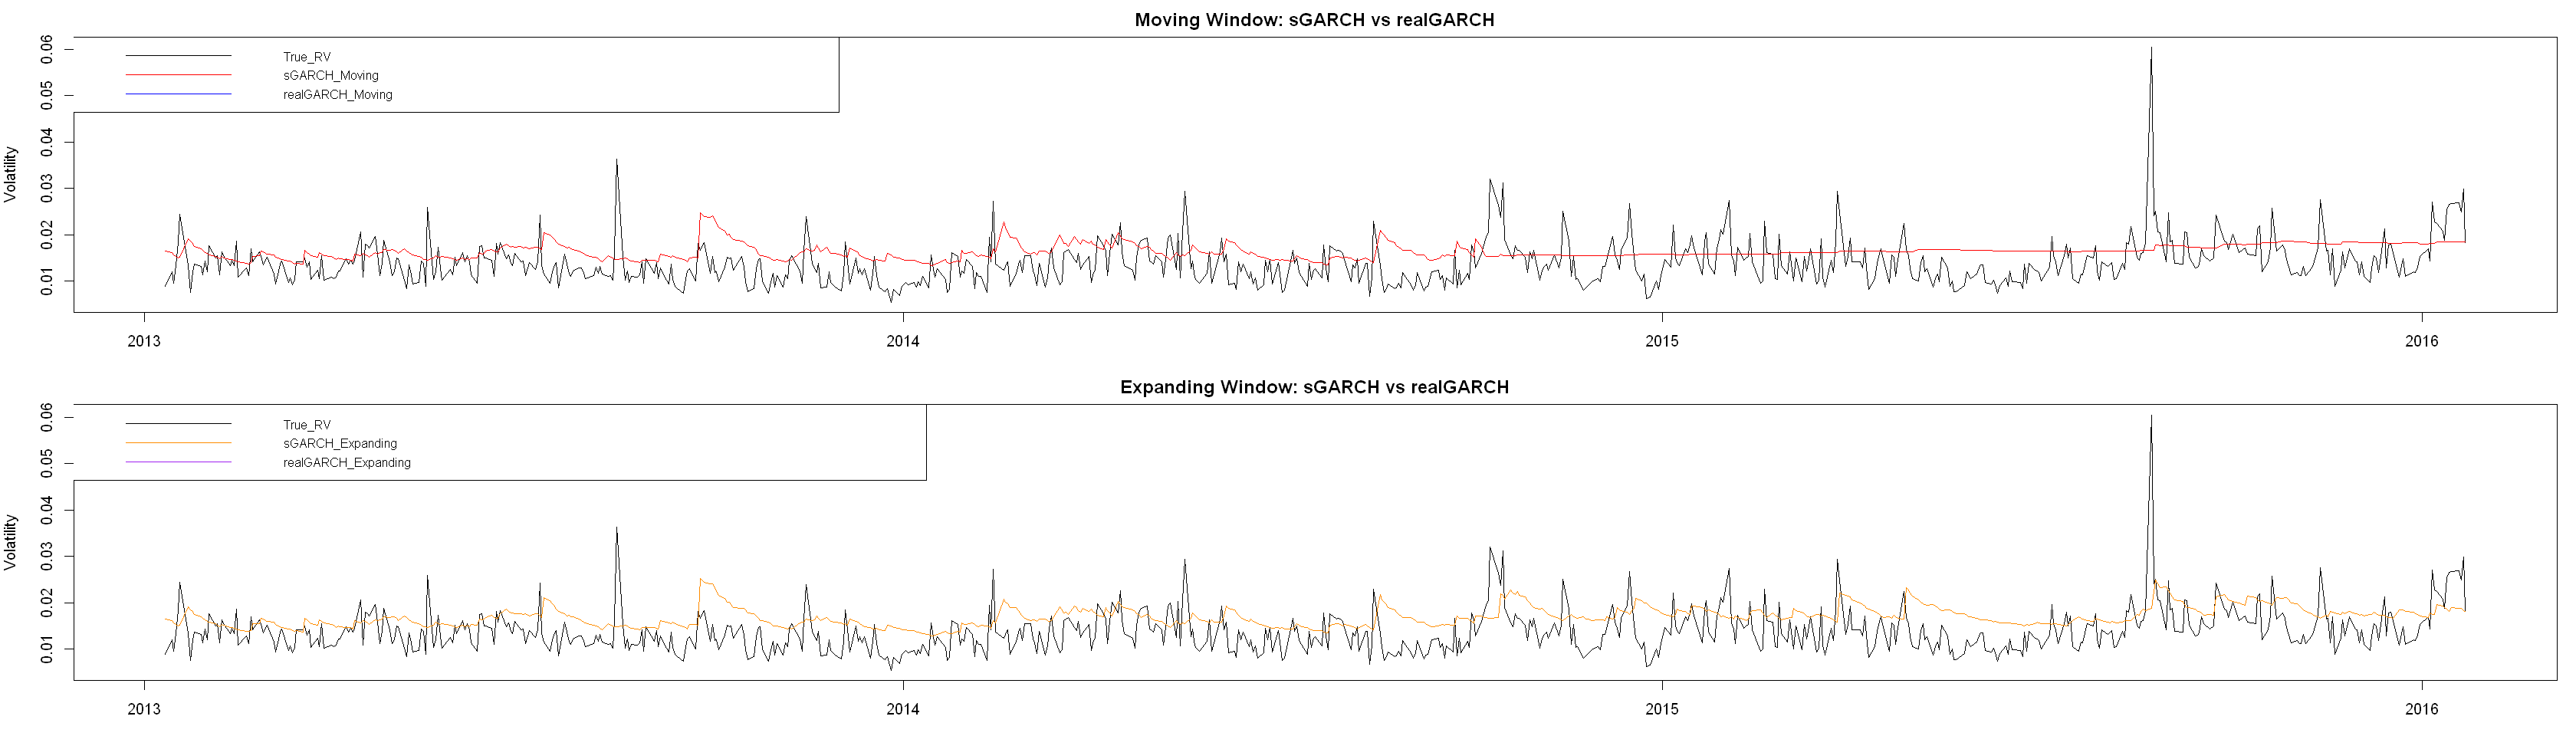

In [56]:

  # =============================================================================
  # OUT-OF-SAMPLE GARCH FORECASTS
  # sGARCH via ugarchroll; realGARCH via a manual rolling loop (ugarchroll discards
  # ALL forecasts if any single window fails). RV is realized volatillity, so every
  # forecast is on the volatility scale (sigma), comparable to RV and the HAR/AR1
  # models. A plausibility guard rejects degenerate "converged" fits whose 1-step
  # forecast blows up (a known rugarch 1.5.4 issue on short early windows).
  # =============================================================================
  set.seed(1)
  cat("rugarch version:", as.character(packageVersion("rugarch")), "\n")  # document the build

  # --- 1. WINDOW LOGIC --------------------------------------------------------
  n_obs           <- nrow(asset_data)
  window_len      <- 750
  n_out_of_sample <- n_obs - window_len
  idx             <- as.Date(index(asset_data))

  # --- 2. DATA: scale x100, jitter zero returns; RV stays a VOLATILITY --------
  safe_ret <- as.numeric(asset_data$ret)
  safe_ret[safe_ret == 0] <- 1e-6
  returns_xts <- xts(safe_ret * 100,                  order.by = idx)
  rv_xts      <- xts(as.numeric(asset_data$RV) * 100, order.by = idx)

  # --- 3. SPECIFICATIONS ------------------------------------------------------
  spec_standard <- ugarchspec(
    variance.model     = list(model = "sGARCH",   garchOrder = c(1, 1)),
    mean.model         = list(armaOrder = c(0, 0), include.mean = FALSE),
    distribution.model = "norm")
  spec_real <- ugarchspec(
    variance.model     = list(model = "realGARCH", garchOrder = c(1, 1)),
    mean.model         = list(armaOrder = c(0, 0), include.mean = FALSE),
    distribution.model = "norm")

  # --- 4. sGARCH via ugarchroll ("recursive" = expanding) ---------------------
  roll_std_mov <- ugarchroll(spec_standard, data = returns_xts, n.ahead = 1,
    forecast.length = n_out_of_sample, refit.every = 5, refit.window = "moving",
    solver = "hybrid", calculate.VaR = FALSE)
  roll_std_exp <- ugarchroll(spec_standard, data = returns_xts, n.ahead = 1,
    forecast.length = n_out_of_sample, refit.every = 5, refit.window = "recursive",
    solver = "hybrid", calculate.VaR = FALSE)

  # --- 5. realGARCH via MANUAL rolling loop (with plausibility guard) ----------
  # Accept a refit only if it converged AND its 1-step forecast is <= 2x the
  # largest realized vol seen in-window. Degenerate fits (huge log-variance
  # intercept -> exploding sigma) are stationary & "converged", so ONLY this
  # forecast cap catches them. On rejection, carry the last good fit forward.
  manual_roll_real <- function(spec, ret, rv, win, refit.every = 5, window = "moving") {
    n <- length(ret); oos <- (win + 1):n
    fc <- rep(NA_real_, length(oos)); fit <- NULL
    for (k in seq_along(oos)) {
      t <- oos[k]
      if (k == 1 || ((k - 1) %% refit.every == 0) || is.null(fit)) {
        lo <- if (window == "moving") (t - win) else 1
        f <- tryCatch(suppressWarnings(ugarchfit(spec, data = ret[lo:(t - 1)],
               realizedVol = rv[lo:(t - 1)], solver = "hybrid",
               fit.control = list(scale = 0))), error = function(e) NULL)
        if (!is.null(f) && f@fit$convergence == 0) {
          cand <- tryCatch(as.numeric(sigma(ugarchforecast(f, n.ahead = 1))),
                           error = function(e) NA)          # scaled sigma
          cap  <- 2 * max(as.numeric(rv[lo:(t - 1)]))       # 2x max in-window RV (scaled)
          if (is.finite(cand) && cand <= cap) fit <- f      # else keep last good fit
        }
      }
      if (!is.null(fit)) {
        fcst <- tryCatch(suppressWarnings(ugarchforecast(fit, n.ahead = 1)),
                         error = function(e) NULL)
        if (!is.null(fcst)) fc[k] <- as.numeric(sigma(fcst))
      }
    }
    xts(fc / 100, order.by = index(ret)[oos])               # un-scale -> volatility
  }

  roll_real_mov <- manual_roll_real(spec_real, returns_xts, rv_xts, window_len, 5, "moving")
  roll_real_exp <- manual_roll_real(spec_real, returns_xts, rv_xts, window_len, 5, "expanding")

  # --- 6. EXTRACT FORECASTS, UN-SCALE TO VOLATILITY (/100) --------------------
  oos_dates    <- tail(idx, n_out_of_sample)
  f_sgarch_mov <- xts(roll_std_mov@forecast$density$Sigma / 100, order.by = oos_dates)
  f_sgarch_exp <- xts(roll_std_exp@forecast$density$Sigma / 100, order.by = oos_dates)
  f_real_mov   <- roll_real_mov
  f_real_exp   <- roll_real_exp
  colnames(f_sgarch_mov) <- "sGARCH_Moving";    colnames(f_sgarch_exp) <- "sGARCH_Expanding"
  colnames(f_real_mov)   <- "realGARCH_Moving"; colnames(f_real_exp)   <- "realGARCH_Expanding"

  actual_rv_oos <- xts(as.numeric(tail(asset_data$RV, n_out_of_sample)), order.by = oos_dates)
  colnames(actual_rv_oos) <- "True_RV"
  plot_data <- merge(actual_rv_oos, f_sgarch_mov, f_sgarch_exp, f_real_mov, f_real_exp)

  # --- 7. PLOT (guarded column selection prevents 'subscript out of bounds') --
  par(mfrow = c(2, 1), mar = c(3, 4, 2, 1))
  mov_cols <- intersect(c("True_RV", "sGARCH_Moving", "realGARCH_Moving"), colnames(plot_data))
  plot.zoo(plot_data[, mov_cols], screens = 1, col = c("black", "red", "blue")[seq_along(mov_cols)],
           main = "Moving Window: sGARCH vs realGARCH", ylab = "Volatility", xlab = "", lwd = 1.3)
  legend("topleft", legend = mov_cols, col = c("black", "red", "blue")[seq_along(mov_cols)], lty = 1, cex = 0.8)
  exp_cols <- intersect(c("True_RV", "sGARCH_Expanding", "realGARCH_Expanding"), colnames(plot_data))
  plot.zoo(plot_data[, exp_cols], screens = 1, col = c("black", "darkorange", "purple")[seq_along(exp_cols)],
           main = "Expanding Window: sGARCH vs realGARCH", ylab = "Volatility", xlab = "Date", lwd = 1.3)
  legend("topleft", legend = exp_cols, col = c("black", "darkorange", "purple")[seq_along(exp_cols)], lty = 1, cex = 0.8)
  par(mfrow = c(1, 1))

### Out-of-sample evaluation

Because `har_data` drops the first 22 observations when constructing the monthly lag, the HAR/AR(1) out-of-sample period (728 days) starts 22 days later than the GARCH one (750 days). To compare models fairly — and because the Diebold–Mariano test compares paired forecast errors day by day — we date every forecast and evaluate **all models on the common 728-day sample** (2013-02-13 → 2016-01-22).

In [42]:
# Date the HAR/AR1 forecasts (currently plain numeric) using har_data's index
har_oos_dates <- index(har_data)[(window_len + 1):nrow(har_data)]
mk <- function(v, nm) { x <- xts(v, order.by = har_oos_dates); colnames(x) <- nm; x }

har_fc <- merge(
mk(fcst_ar1_roll,       "AR1_Roll"),  mk(fcst_har_roll,       "HAR_Roll"),
mk(fcst_har_rs_roll,    "HARRS_Roll"),mk(fcst_har_rs_rk_roll, "HARRSRK_Roll"),
mk(fcst_ar1_exp,        "AR1_Exp"),   mk(fcst_har_exp,        "HAR_Exp"),
mk(fcst_har_rs_exp,     "HARRS_Exp"), mk(fcst_har_rs_rk_exp,  "HARRSRK_Exp"))

# GARCH forecasts (already xts, volatility units); relabel to match the scheme
g_sgarch_roll <- f_sgarch_mov; colnames(g_sgarch_roll) <- "sGARCH_Roll"
g_real_roll   <- f_real_mov;   colnames(g_real_roll)   <- "realGARCH_Roll"
g_sgarch_exp  <- f_sgarch_exp; colnames(g_sgarch_exp)  <- "sGARCH_Exp"
g_real_exp    <- f_real_exp;   colnames(g_real_exp)    <- "realGARCH_Exp"

true_rv <- xts(as.numeric(asset_data$RV), order.by = as.Date(index(asset_data)))
colnames(true_rv) <- "True_RV"

# Align everything on the common dates (intersection -> 728 days)
eval_xts <- na.omit(merge(true_rv, har_fc,
                        g_sgarch_roll, g_real_roll, g_sgarch_exp, g_real_exp))
actual  <- as.numeric(eval_xts$True_RV)
fc_cols <- setdiff(colnames(eval_xts), "True_RV")
cat(sprintf("Aligned evaluation sample: %d days, %s to %s\n",
          nrow(eval_xts), start(eval_xts), end(eval_xts)))



Aligned evaluation sample: 728 days, 2013-02-13 to 2016-01-22


In [43]:
loss_tab <- t(sapply(fc_cols, function(cn) {
e <- actual - as.numeric(eval_xts[, cn]); c(MSE = mean(e^2), MAE = mean(abs(e)))
}))
cat("--- OUT-OF-SAMPLE LOSS (common 728-day sample) ---\n")
print(round(loss_tab, 8))

--- OUT-OF-SAMPLE LOSS (common 728-day sample) ---
                     MSE        MAE
AR1_Roll       1.720e-05 0.00289612
HAR_Roll       1.603e-05 0.00276971
HARRS_Roll     1.599e-05 0.00276796
HARRSRK_Roll   1.569e-05 0.00276138
AR1_Exp        1.718e-05 0.00293730
HAR_Exp        1.577e-05 0.00277631
HARRS_Exp      1.571e-05 0.00277204
HARRSRK_Exp    1.543e-05 0.00276319
sGARCH_Roll    2.806e-05 0.00422259
realGARCH_Roll 1.934e-05 0.00320936
sGARCH_Exp     3.031e-05 0.00447324
realGARCH_Exp  3.069e-05 0.00375504


### Plotting forecast errors - GARCH models

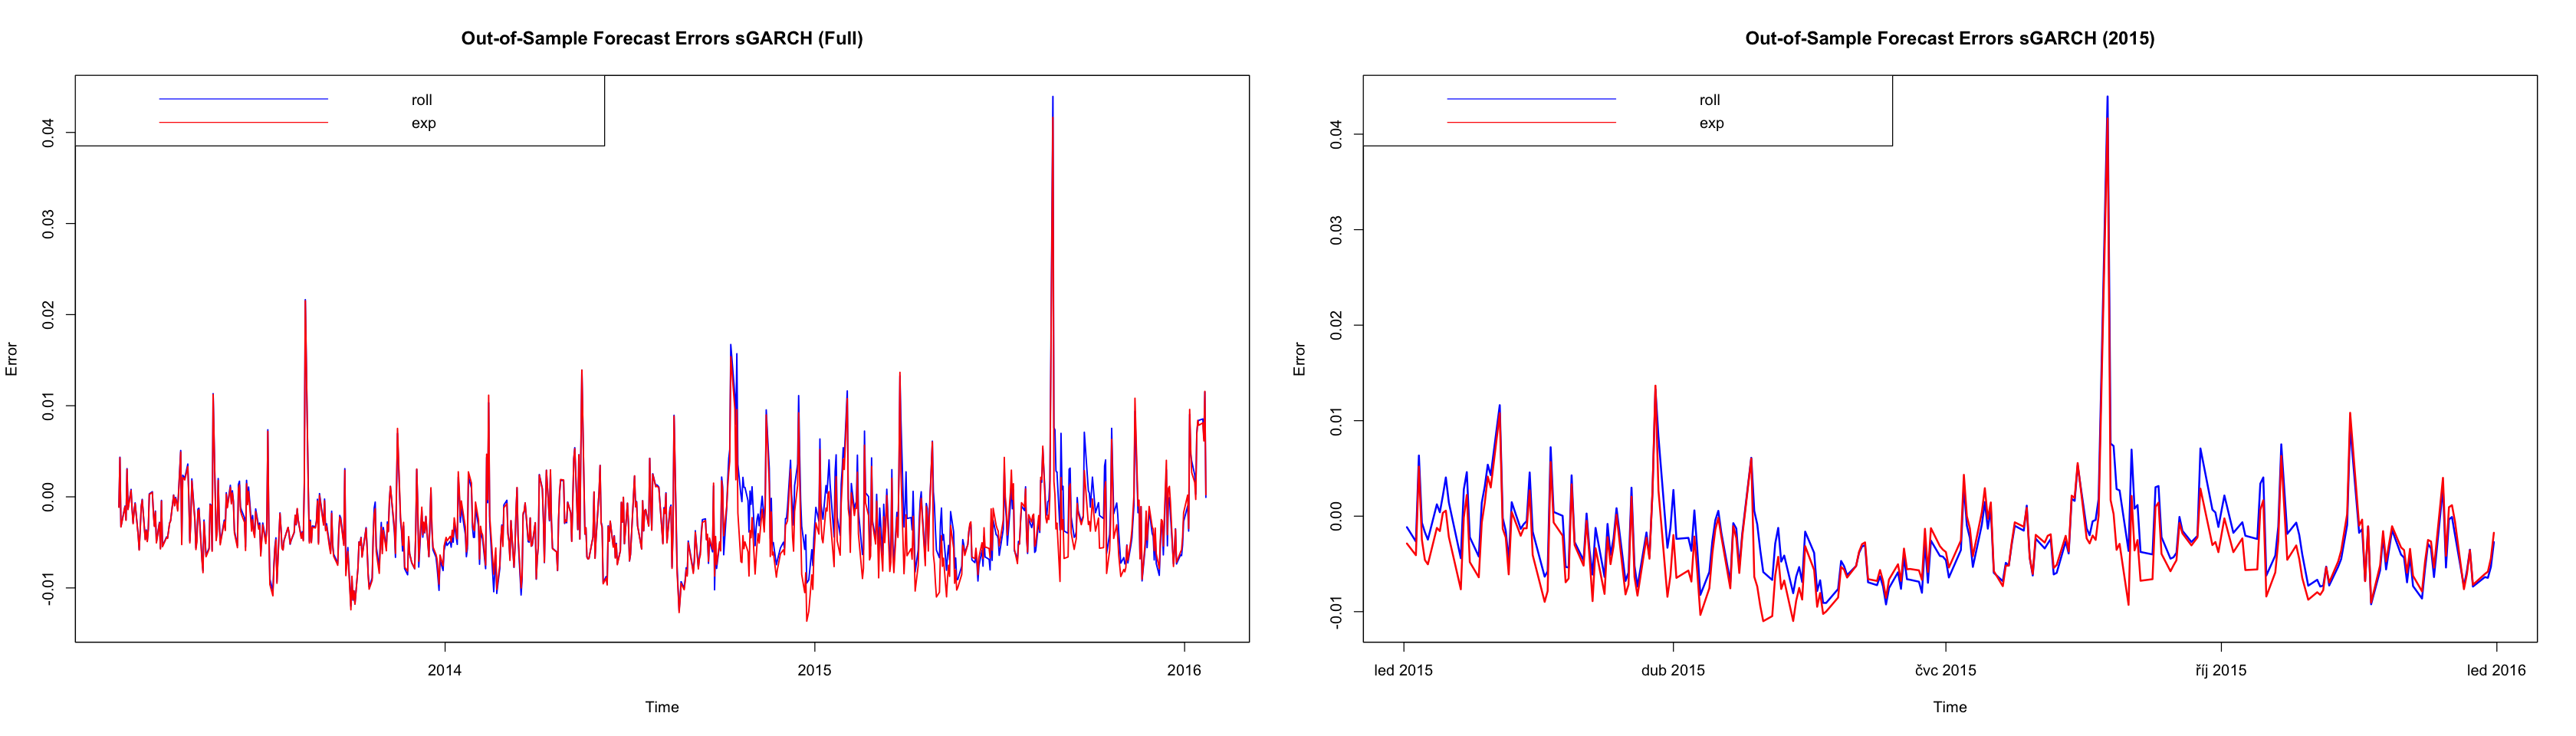

In [49]:
# ---- sGARCH forecast errors (rolling vs expanding) ----
options(repr.plot.width = 28, repr.plot.height = 8)

err_sgarch_roll <- eval_xts$True_RV - eval_xts$sGARCH_Roll
err_sgarch_exp  <- eval_xts$True_RV - eval_xts$sGARCH_Exp
sgarch_errors      <- merge(err_sgarch_roll, err_sgarch_exp)
sgarch_errors_2015 <- sgarch_errors["2015"]

par(mfrow = c(1, 2))
zoo::plot.zoo(sgarch_errors, plot.type = "single",
          col = c("blue", "red"), lwd = 1.5,
          main = "Out-of-Sample Forecast Errors sGARCH (Full)",
          ylab = "Error", xlab = "Time")
legend("topleft", legend = c("roll", "exp"), col = c("blue", "red"), lty = 1)

zoo::plot.zoo(sgarch_errors_2015, plot.type = "single",
          col = c("blue", "red"), lwd = 2,
          main = "Out-of-Sample Forecast Errors sGARCH (2015)",
          ylab = "Error", xlab = "Time")
legend("topleft", legend = c("roll", "exp"), col = c("blue", "red"), lty = 1)
par(mfrow = c(1, 1))

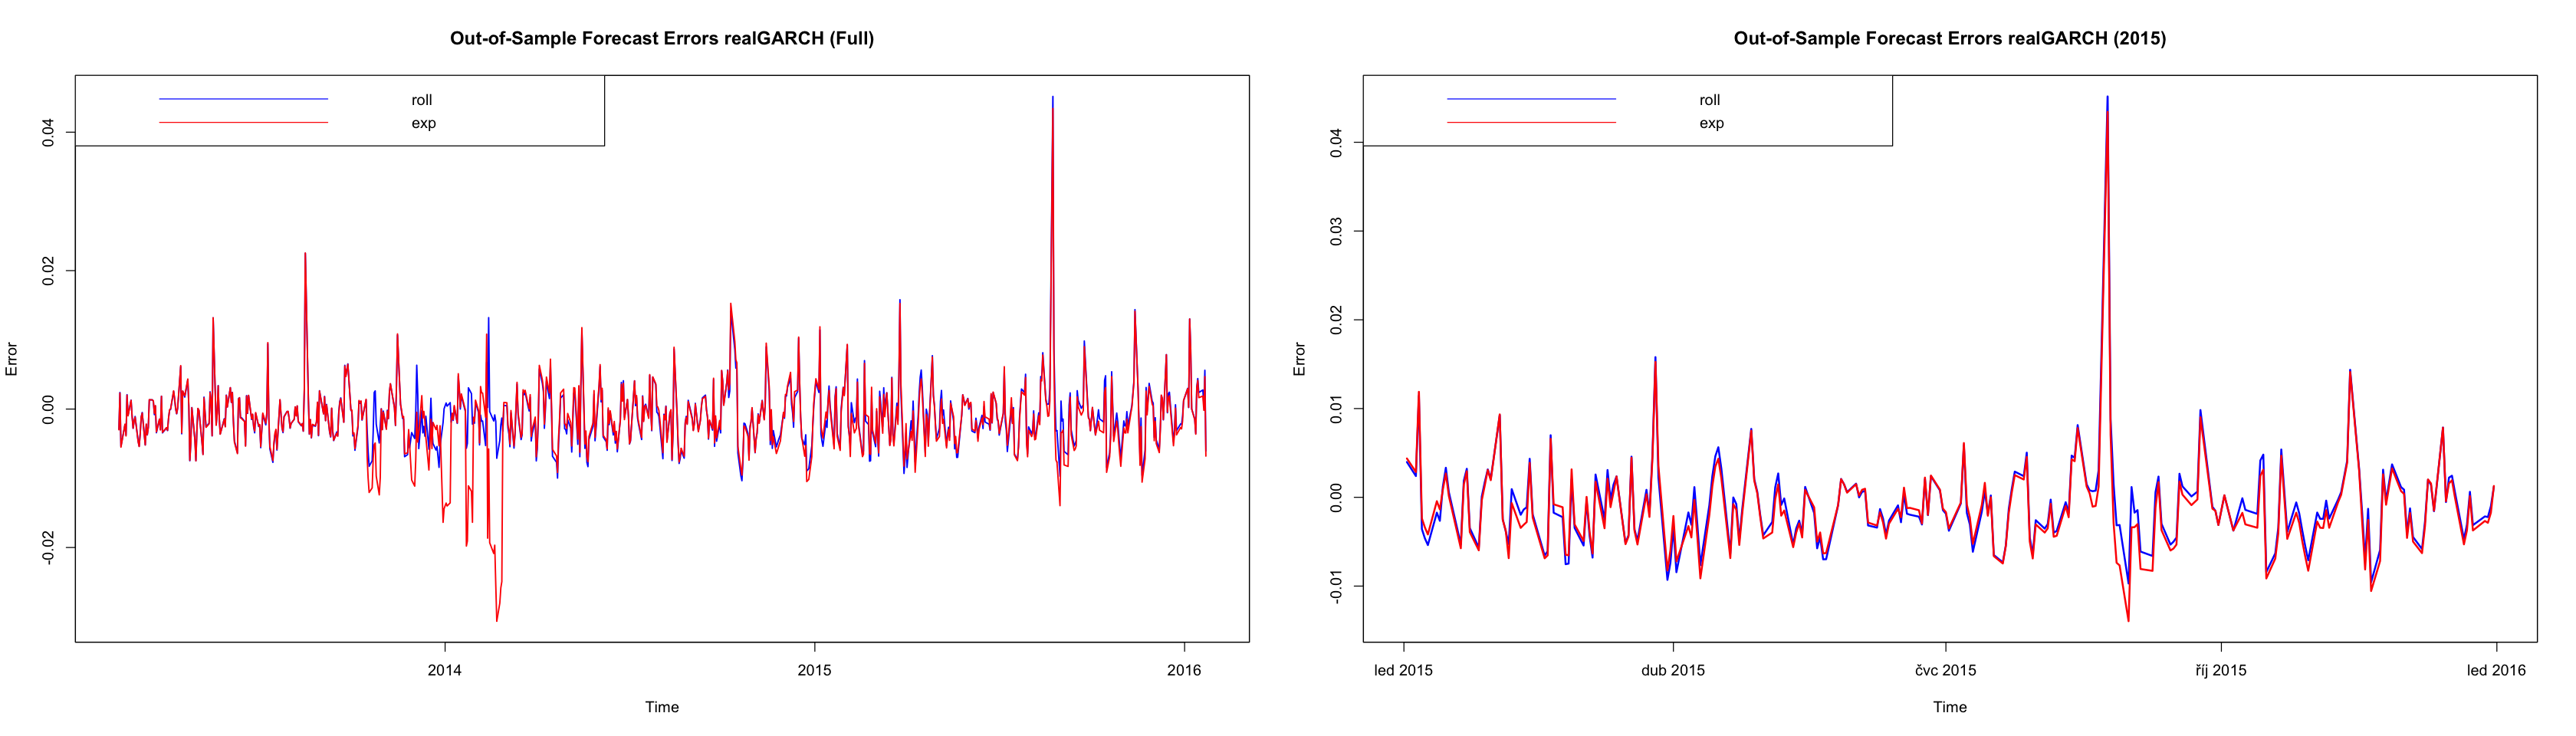

In [50]:
# ---- realGARCH forecast errors (rolling vs expanding) ----
options(repr.plot.width = 28, repr.plot.height = 8)

err_real_roll <- eval_xts$True_RV - eval_xts$realGARCH_Roll
err_real_exp  <- eval_xts$True_RV - eval_xts$realGARCH_Exp
real_errors      <- merge(err_real_roll, err_real_exp)
real_errors_2015 <- real_errors["2015"]

par(mfrow = c(1, 2))
zoo::plot.zoo(real_errors, plot.type = "single",
          col = c("blue", "red"), lwd = 1.5,
          main = "Out-of-Sample Forecast Errors realGARCH (Full)",
          ylab = "Error", xlab = "Time")
legend("topleft", legend = c("roll", "exp"), col = c("blue", "red"), lty = 1)

zoo::plot.zoo(real_errors_2015, plot.type = "single",
          col = c("blue", "red"), lwd = 2,
          main = "Out-of-Sample Forecast Errors realGARCH (2015)",
          ylab = "Error", xlab = "Time")
legend("topleft", legend = c("roll", "exp"), col = c("blue", "red"), lty = 1)
par(mfrow = c(1, 1))

In [47]:
# MSE-loss Diebold-Mariano (power = 2, h = 1). p < 0.05 => accuracy differs.
dm_p <- function(a, b) {
e1 <- actual - as.numeric(eval_xts[, a])
e2 <- actual - as.numeric(eval_xts[, b])
o <- tryCatch(dm.test(e1, e2, alternative = "two.sided", h = 1, power = 2), error = function(e) NULL)
if (is.null(o)) NA else round(o$p.value, 4)
}

cat("--- DIEBOLD-MARIANO p-values vs HAR baseline (MSE loss) ---\n\n")
cat("Rolling:\n")
for (m in c("AR1_Roll","HARRS_Roll","HARRSRK_Roll","sGARCH_Roll","realGARCH_Roll")) {
cat(sprintf("  HAR_Roll vs %-15s p = %s\n", m, dm_p("HAR_Roll", m)))
}
cat("\nExpanding:\n")
for (m in c("AR1_Exp","HARRS_Exp","HARRSRK_Exp","sGARCH_Exp","realGARCH_Exp")) {
cat(sprintf("  HAR_Exp  vs %-15s p = %s\n", m, dm_p("HAR_Exp", m)))
}

--- DIEBOLD-MARIANO p-values vs HAR baseline (MSE loss) ---

Rolling:
  HAR_Roll vs AR1_Roll        p = 0.0014
  HAR_Roll vs HARRS_Roll      p = 0.6472
  HAR_Roll vs HARRSRK_Roll    p = 0.0557
  HAR_Roll vs sGARCH_Roll     p = 0
  HAR_Roll vs realGARCH_Roll  p = 0

Expanding:
  HAR_Exp  vs AR1_Exp         p = 0.0035
  HAR_Exp  vs HARRS_Exp       p = 0.5103
  HAR_Exp  vs HARRSRK_Exp     p = 0.0617
  HAR_Exp  vs sGARCH_Exp      p = 0
  HAR_Exp  vs realGARCH_Exp   p = 0


In [48]:
# Regress actual on each forecast: RV_t = a + b*forecast_t + u_t
# Joint H0: a = 0 AND b = 1 (forecast is unbiased/efficient). p < 0.05 => reject.
mz_tab <- t(sapply(fc_cols, function(cn) {
f <- as.numeric(eval_xts[, cn]); m <- lm(actual ~ f)
b <- coef(m); V <- vcov(m); d <- c(b[1] - 0, b[2] - 1)
Fstat <- as.numeric(t(d) %*% solve(V) %*% d) / 2
c(a = b[1], b = b[2], R2 = summary(m)$r.squared,
  F = Fstat, p_joint = pf(Fstat, 2, length(actual) - 2, lower.tail = FALSE))
}))
cat("--- MINCER-ZARNOWITZ (joint H0: a=0, b=1) ---\n")
print(round(mz_tab, 5))

--- MINCER-ZARNOWITZ (joint H0: a=0, b=1) ---
               a.(Intercept)     b.f      R2         F p_joint
AR1_Roll             0.00161 0.87489 0.18195   2.10107 0.12307
HAR_Roll             0.00029 0.98576 0.23359   0.21155 0.80938
HARRS_Roll           0.00037 0.98136 0.23578   0.32907 0.71970
HARRSRK_Roll         0.00033 0.98358 0.24997   0.28786 0.74995
AR1_Exp              0.00285 0.76165 0.21630  17.59654 0.00000
HAR_Exp              0.00145 0.88751 0.25029   2.26483 0.10458
HARRS_Exp            0.00148 0.88756 0.25303   2.15443 0.11671
HARRSRK_Exp          0.00141 0.89304 0.26584   2.04083 0.13067
sGARCH_Roll          0.00808 0.35202 0.01477 131.55469 0.00000
realGARCH_Roll       0.00410 0.65778 0.16510  39.19944 0.00000
sGARCH_Exp           0.00480 0.53343 0.06083 197.38624 0.00000
realGARCH_Exp        0.00943 0.28618 0.06584 207.53016 0.00000
